<a href="https://colab.research.google.com/github/AntonDozhdikov/politpredict/blob/main/BRICS_PolSys_MARL_v8_0_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BRICS–PolSys MARL v8.0

**Финальный воспроизводимый контрфактический эксперимент для приложения к политологической статье**

V8 сохраняет проверенную онтологию из 47 состояний, 14 действий и обучающий контур
`DNLSSM → MAPPO → MWA/NES → MetaBRICS`, но меняет содержательный центр эксперимента.
Локальная адаптация оценивается по эффективности и функциональным потерям, а наднациональный
supervisor — по способности защищать наиболее уязвимых участников коалиции, ограничивать
неравномерность потерь и сохранять среднюю результативность.

Ноутбук рассчитан на последовательный запуск в Google Colab с NVIDIA T4/L4. Производственный
режим использует десять сидов, общий вычислительный регулятор, раннюю остановку и жёсткий предел
235 минут. Это модельный контрфактический эксперимент, а не прогноз, рейтинг стран или рекомендация
реальным правительствам.

## Научный статус и границы вывода

Единица первичного статистического вывода — **обучающий seed**, внутри которого находятся
сценарии. Доверительные интервалы строятся иерархическим bootstrap, а permutation/sign-flip
переворачивает знак целиком для всех сценариев одного seed. Страны и временные шаги являются
вложенными наблюдениями и не используются как независимые репликации.

Наблюдавшийся holdout 2021–2025 проверяет перенос на не использовавшийся при обучении период.
Synthetic OOD 2026–2036 — зарегистрированный модельный стресс-тест с многофазными,
асимметричными и составными кризисами; это не наблюдение будущего. Primary-гипотезы корректируются
Holm, exploratory — FDR-BH. Эффект всегда сообщается вместе с исходной величиной, 95% CI и SESOI.

`I_PolSys` остаётся эндогенной постоценкой рассчитанных траекторий и не интерпретируется как
универсальная шкала политических режимов.

## Карта исполнения

| Контур | Содержание | Ожидаемое окно |
|---|---|---:|
| Preflight | схема, train-only преобразования, сценарный реестр, GPU-probe | 6–9 мин |
| Exp.0 | ансамбль из пяти DNLSSM и глобально-страновой gate | 6–25 мин |
| Exp.1 | 10 независимых MAPPO/CTDE политик | 55–70 мин |
| Exp.2.1 | MWA/NES только для референтной страны | 7–12 мин |
| Exp.2.2 | локальный MWA/NES для каждой страны | 70–85 мин |
| Exp.2.3 | MetaBRICS: mean–floor–cohesion objective | 8–22 мин |
| Evaluation + Exp.3 | holdout/OOD, функциональные и распределительные потери | 10–20 мин |
| Statistics + figures + export | 17 гипотез, Excel, PNG/SVG и ZIP | 15–25 мин |

Один текстовый progress-bar совместим и с Colab, и со статическим отображением на GitHub.
Служебные checkpoint и cache в итоговый архив не включаются.

## 0. Среда Colab

Выберите **Runtime → Change runtime type → T4 GPU или L4 GPU**, затем выполните ячейки сверху вниз. Установочная ячейка добавляет только отсутствующие библиотеки и не заменяет поставляемую Colab версию PyTorch/CUDA.


In [1]:
# Устанавливаем только отсутствующие пакеты: это снижает риск конфликта с CUDA-стеком Colab.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "openpyxl": "openpyxl>=3.1",
    "xlsxwriter": "xlsxwriter>=3.2",
    "pyarrow": "pyarrow>=17",
    "statsmodels": "statsmodels>=0.14",
    "seaborn": "seaborn>=0.13",
}

missing = [spec for module, spec in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Среда готова; PyTorch/CUDA не переустанавливались.")


Среда готова; PyTorch/CUDA не переустанавливались.


In [2]:
# Базовые зависимости и единый визуальный стиль.
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import random
import shutil
import time
import textwrap
import warnings
import zipfile
from collections import defaultdict
from contextlib import contextmanager
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as sps
import statsmodels.formula.api as smf
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.special import expit
from statsmodels.stats.multitest import multipletests
from torch.distributions import Dirichlet, Normal
from torch.func import functional_call, vmap
from torch.utils.data import DataLoader, TensorDataset
from tqdm.std import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CUDA_ENABLED = DEVICE.type == "cuda"
if CUDA_ENABLED:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = False
    torch.set_float32_matmul_precision("high")

print(f"Устройство: {DEVICE}")
if CUDA_ENABLED:
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Устройство: cuda
GPU: Tesla T4


In [3]:
def set_global_seed(seed: int) -> None:
    """Фиксирует генераторы; детерминированные операции включаются в безопасном warn-only режиме."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if CUDA_ENABLED:
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)


def stable_int_seed(*parts: Any) -> int:
    digest = hashlib.sha256("|".join(map(str, parts)).encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def cleanup_memory() -> None:
    gc.collect()
    if CUDA_ENABLED:
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


set_global_seed(17)


## 1. Конфигурация и вычислительный бюджет

`STANDARD` — основной профиль для L4/T4; `SAFE_T4` уменьшает только верхние пределы обучения.
Число сидов, горизонт оценки, holdout/OOD-разбиение и реестр гипотез не сокращаются.

Новые параметры V8 явно задают: многофазность OOD-шоков, чувствительность страновой экспозиции,
долю стран в tail-CVaR и целевую функцию MetaBRICS. Все значения экспортируются в лист `Design`.

In [4]:
@dataclass(frozen=True)
class ComputeProfile:
    name: str
    wm_min_epochs: int
    wm_max_epochs: int
    mappo_min_episodes: int
    mappo_max_episodes: int
    nes_min_rounds: int
    nes_max_rounds: int
    meta_min_rounds: int
    meta_max_rounds: int


PROFILES = {
    "STANDARD": ComputeProfile("STANDARD", 70, 180, 350, 600, 45, 90, 60, 100),
    "SAFE_T4": ComputeProfile("SAFE_T4", 60, 150, 300, 500, 40, 75, 50, 85),
}


@dataclass
class ExperimentConfig:
    project: str = "BRICS-PolSys-MARL"
    version: str = "8.0"
    seeds: tuple[int, ...] = (17, 42, 101, 202, 303, 404, 505, 606, 707, 808)
    countries: tuple[str, ...] = ("RUS", "CHN", "IND", "BRA", "ZAF", "IRN", "ARE", "ETH", "EGY", "IDN")
    reference_country: str = "RUS"

    train_year_end: int = 2020
    holdout_year_start: int = 2021
    holdout_year_end: int = 2025
    ood_year_start: int = 2026
    ood_year_end: int = 2036
    horizon: int = 40
    n_eval_observed: int = 3
    n_eval_ood: int = 6

    n_state: int = 47
    n_actions: int = 14
    n_agents: int = 10
    channel_weights: tuple[float, float, float] = (0.50, 0.25, 0.25)

    wm_members: int = 5
    wm_hidden: int = 160
    wm_layers: int = 3
    wm_batch: int = 256
    wm_lr: float = 8e-4
    wm_residual_scale: float = 0.05
    wm_patience: int = 24
    wm_required_ratio: float = 0.995
    wm_required_median_country_ratio: float = 1.00
    wm_max_country_ratio: float = 1.08

    actor_hidden: tuple[int, int, int] = (256, 128, 64)
    gamma: float = 0.975
    gae_lambda: float = 0.95
    mappo_lr: float = 2.5e-4
    clip_eps: float = 0.20
    update_epochs: int = 8
    minibatches: int = 4
    entropy_coef: float = 0.012
    value_coef: float = 0.50
    max_grad_norm: float = 0.50
    update_every_episodes: int = 4
    rl_patience: int = 40
    rl_rel_delta: float = 0.0005

    mwa_hidden: int = 64
    mwa_max_logit_shift: float = 1.25
    nes_population: int = 12
    nes_sigma: float = 0.075
    nes_lr: float = 0.035
    nes_patience: int = 16
    nes_scenarios_per_round: int = 2

    meta_hidden: int = 160
    meta_lr: float = 2e-4
    meta_patience: int = 20
    meta_max_logit_shift: float = 0.75
    dirichlet_concentration: float = 24.0
    supervisor_kl_coef: float = 0.01
    meta_entropy_coef: float = 0.001
    meta_mean_weight: float = 0.55
    meta_floor_weight: float = 0.30
    meta_cohesion_weight: float = 0.15
    meta_inequality_penalty: float = 0.10
    meta_floor_fraction: float = 0.20

    # Цена возникает только при фактической перенастройке, неопределённости или proxy drift.
    coord_penalty: float = 0.006
    uncertainty_penalty: float = 0.010
    proxy_drift_penalty: float = 0.010
    standardized_sesoi: float = 0.10
    tail_cvar_fraction: float = 0.20

    # Многофазный стресс-дизайн применяется только к synthetic OOD.
    ood_stress_floor: float = 1.15
    ood_stress_ceiling: float = 1.35
    ood_aftershock_ratio: float = 0.45
    ood_tail_decay: float = 0.10
    observed_aftershock_ratio: float = 0.15
    observed_tail_decay: float = 0.18
    vulnerability_exposure_strength: float = 0.35

    recovery_baseline_window: int = 3
    recovery_sustain_periods: int = 4
    recovery_tolerance_floor: float = 0.006
    recovery_volatility_multiplier: float = 0.75

    target_runtime_min: int = 175
    target_runtime_max: int = 220
    hard_runtime_min: int = 235
    finalization_reserve_min: int = 20
    stage_budget_min: dict[str, float] = field(default_factory=lambda: {
        "Preflight":8, "Exp.0":25, "Exp.1":65, "Exp.2.1":10,
        "Exp.2.2":82, "Exp.2.3":22, "Evaluation":16,
        "Exp.3":6, "Statistics":10, "Figures":5, "Export":8,
    })

    input_mode: str = "upload"             # upload | github
    panel_filename: str = "brics_polsys_panel_v2_full.xlsx"
    crisis_filename: str = "crises_and_scenarios_generated.xlsx"
    panel_url: str = ""
    crisis_url: str = ""
    output_root: str = "/content/BRICS_PolSys_MARL_v8_0_results"
    work_root: str = "/content/BRICS_PolSys_MARL_v8_0_work"
    resume: bool = True
    keep_checkpoints: bool = False
    export_full_mechanism_steps: bool = False


CFG = ExperimentConfig()
PROFILE = PROFILES["STANDARD"]
print(json.dumps({**asdict(CFG), "profile":asdict(PROFILE)}, ensure_ascii=False, indent=2))

{
  "project": "BRICS-PolSys-MARL",
  "version": "8.0",
  "seeds": [
    17,
    42,
    101,
    202,
    303,
    404,
    505,
    606,
    707,
    808
  ],
  "countries": [
    "RUS",
    "CHN",
    "IND",
    "BRA",
    "ZAF",
    "IRN",
    "ARE",
    "ETH",
    "EGY",
    "IDN"
  ],
  "reference_country": "RUS",
  "train_year_end": 2020,
  "holdout_year_start": 2021,
  "holdout_year_end": 2025,
  "ood_year_start": 2026,
  "ood_year_end": 2036,
  "horizon": 40,
  "n_eval_observed": 3,
  "n_eval_ood": 6,
  "n_state": 47,
  "n_actions": 14,
  "n_agents": 10,
  "channel_weights": [
    0.5,
    0.25,
    0.25
  ],
  "wm_members": 5,
  "wm_hidden": 160,
  "wm_layers": 3,
  "wm_batch": 256,
  "wm_lr": 0.0008,
  "wm_residual_scale": 0.05,
  "wm_patience": 24,
  "wm_required_ratio": 0.995,
  "wm_required_median_country_ratio": 1.0,
  "wm_max_country_ratio": 1.08,
  "actor_hidden": [
    256,
    128,
    64
  ],
  "gamma": 0.975,
  "gae_lambda": 0.95,
  "mappo_lr": 0.00025,
  "clip_eps

## 2. Онтология состояния и действий

Состояние страны $i$ в момент $t$ — вектор

$$s_{i,t}=[D_{12},W_{8},M_{6},Q_{6},X_{4},K_{4},Z_{7}]\in[0,1]^{47},$$

где $D$ — «дела», $W$ — «слова», $M$ — публичные «образы», $Q$ — структурный фон, $X$ — кризисные признаки, $K=(SDI,ECI,MPI,DPI)$ — четыре системных индекса, $Z=(L,S,P,G,I,O,T)$ — стратегико-коммуникационные переменные. Порядок признаков является частью спецификации и защищён SHA-256.

Действие $a_{i,t}\in[-1,1]^{14}$ содержит четыре инструмента «дел», четыре инструмента «слов», три инструмента «образов» и три структурных инструмента. Адаптивные веса применяются только к первым трём каналам; структурный блок остаётся отдельным.


In [5]:
STATE_BLOCKS = {
    "deeds": [
        "gdp_growth_final", "gdp_per_capita", "trade_openness_final", "fdi_inflow_pct_gdp",
        "gross_capital_form_wdi", "exports_gdp_wdi", "imports_gdp_wdi", "manufacturing_gdp_wdi",
        "military_spending_gdp_final", "hitech_exports_wdi", "rd_gdp_wdi", "patents_residents_wdi",
    ],
    "words": [
        "electoral_democracy_vdem", "liberal_democracy_vdem", "political_corruption_vdem",
        "voice_accountability", "political_stability", "regulatory_quality", "rule_of_law",
        "control_of_corruption",
    ],
    "images": [
        "corruption_perception", "government_effectiveness", "internet_users_final",
        "mobile_subs_wdi", "broadband_wdi", "secure_servers_pm_wdi",
    ],
    "structural": [
        "population_growth_rate", "urbanization", "dependency_ratio", "net_migration_wb",
        "gini_index_final", "unemployment_final",
    ],
    "shocks": ["active_crisis_flag", "sanction_severity", "anomaly_score", "elite_pressure_index"],
    "core": ["SDI", "ECI", "MPI", "DPI"],
    "strategic": [
        "L_internal_legitimacy_proxy", "S_narrative_sync_proxy", "P_external_pressure_constructed",
        "G_ai_tech_gap_proxy", "I_institutional_maturity_constructed",
        "O_regional_operationalization_proxy", "T_audience_trust_proxy",
    ],
}
STATE_NAMES = tuple(name for block in STATE_BLOCKS.values() for name in block)
STATE_INDEX = {name: i for i, name in enumerate(STATE_NAMES)}
# Каноническое представление онтологии: одно имя показателя на строку.
# Именно по нему рассчитана опубликованная контрольная сумма.
STATE_ORDER_SHA256 = hashlib.sha256("\n".join(STATE_NAMES).encode("utf-8")).hexdigest()
EXPECTED_STATE_SHA256 = "407edb27a53044727d10e5983637ad4a3ac0739fccc16e7ca07c82bc5ba2243c"

STATE_DEFINITIONS = {
    "gdp_growth_final": "темп роста ВВП", "gdp_per_capita": "ВВП на душу населения",
    "trade_openness_final": "внешнеторговая открытость", "fdi_inflow_pct_gdp": "приток ПИИ, % ВВП",
    "gross_capital_form_wdi": "валовое накопление капитала", "exports_gdp_wdi": "экспорт, % ВВП",
    "imports_gdp_wdi": "импорт, % ВВП", "manufacturing_gdp_wdi": "обрабатывающая промышленность, % ВВП",
    "military_spending_gdp_final": "военные расходы, % ВВП", "hitech_exports_wdi": "высокотехнологичный экспорт",
    "rd_gdp_wdi": "НИОКР, % ВВП", "patents_residents_wdi": "патентные заявки резидентов",
    "electoral_democracy_vdem": "электорально-демократический компонент V-Dem",
    "liberal_democracy_vdem": "либерально-демократический компонент V-Dem",
    "political_corruption_vdem": "политическая коррупция V-Dem; больше означает хуже",
    "voice_accountability": "участие и подотчётность", "political_stability": "политическая стабильность",
    "regulatory_quality": "качество регулирования", "rule_of_law": "верховенство права",
    "control_of_corruption": "контроль коррупции", "corruption_perception": "восприятие чистоты публичного управления",
    "government_effectiveness": "эффективность правительства", "internet_users_final": "пользователи интернета",
    "mobile_subs_wdi": "мобильные подключения", "broadband_wdi": "фиксированный широкополосный доступ",
    "secure_servers_pm_wdi": "защищённые серверы на миллион человек", "population_growth_rate": "рост населения",
    "urbanization": "доля городского населения", "dependency_ratio": "демографическая нагрузка",
    "net_migration_wb": "чистая миграция", "gini_index_final": "неравенство Джини; больше означает хуже",
    "unemployment_final": "безработица; больше означает хуже", "active_crisis_flag": "активность кризиса",
    "sanction_severity": "интенсивность санкционного давления", "anomaly_score": "аномальность траектории",
    "elite_pressure_index": "давление на элитную коалицию", "SDI": "Social Development Index",
    "ECI": "Elite Concentration Index", "MPI": "Material Power Index",
    "DPI": "Destructive Potential Index = rescale(ECI) × rescale(MPI)",
    "L_internal_legitimacy_proxy": "L: внутренняя легитимность",
    "S_narrative_sync_proxy": "S: согласованность нарратива",
    "P_external_pressure_constructed": "P: внешнее давление",
    "G_ai_tech_gap_proxy": "G: технологический разрыв",
    "I_institutional_maturity_constructed": "I: институциональная зрелость",
    "O_regional_operationalization_proxy": "O: операционализация обязательств",
    "T_audience_trust_proxy": "T: доверие аудитории",
}

ACTION_GROUPS = {
    "deeds": (0, 1, 2, 3), "words": (4, 5, 6, 7),
    "images": (8, 9, 10), "structural": (11, 12, 13),
}
ACTION_NAMES = (
    "trade_intensity_brics", "ndb_investment", "bilateral_preferences", "fdi_openness",
    "unga_alignment_brics", "initiate_declaration", "support_member", "multilateral_forum",
    "media_coverage_intensity", "narrative_tone", "counter_disinfo_ops",
    "migration_policy", "education_exchange", "elite_stabilization",
)
ACTION_DEFINITIONS = {
    "trade_intensity_brics": "интенсивность взаимной торговли", "ndb_investment": "инвестиции НБР",
    "bilateral_preferences": "двусторонние преференции", "fdi_openness": "открытость для ПИИ",
    "unga_alignment_brics": "согласование позиций в ГА ООН", "initiate_declaration": "инициирование декларации",
    "support_member": "публичная поддержка участника", "multilateral_forum": "многосторонняя координация",
    "media_coverage_intensity": "интенсивность медиаприсутствия", "narrative_tone": "тон нарратива",
    "counter_disinfo_ops": "информационная устойчивость", "migration_policy": "миграционная политика",
    "education_exchange": "образовательные и экспертные обмены", "elite_stabilization": "элитное согласование",
}

assert len(STATE_NAMES) == 47 and STATE_ORDER_SHA256 == EXPECTED_STATE_SHA256
assert len(ACTION_NAMES) == 14
print(f"Онтология: {len(STATE_NAMES)} состояний, {len(ACTION_NAMES)} действий; SHA-256 подтверждён.")


Онтология: 47 состояний, 14 действий; SHA-256 подтверждён.


## 3. Индексы, ориентация показателей и функция вознаграждения

SDI, ECI и MPI строятся только на обучающем периоде 1990–2020; DPI определяется как
$DPI=ECI\times MPI$. Для положительных признаков используется $x$, для отрицательных $1-x$,
для нейтральных признаков — устойчивое расстояние от train-медианы.

Канальные результаты $Y_D,Y_W,Y_M$ — средние ориентированных признаков. Награды:

$$R_{gross}=.30Y_D+.25Y_W+.15Y_M+.20Coh-.10Risk,$$

$$R_{net}=R_{gross}-.006C_{coord}-.010U-.010ProxyDrift.$$

Штрафы одинаковы для всех архитектур и зависят только от наблюдаемой перенастройки,
неопределённости ансамбля и расхождения символического и операционального контуров.

In [6]:
INDEX_SPECS = {
    "SDI": {
        "positive": ("edu_exp_pct_gdp", "health_exp_pct_gdp", "life_expectancy", "electricity_access", "water_basic_access", "social_contrib_pct_gdp"),
        "negative": ("poverty_headcount",),
        "minimum_coverage": 5,
    },
    "ECI": {
        "positive": ("gini_wb", "income_top20", "tax_revenue_pct_gdp", "npl_pct", "private_credit_pct_gdp"),
        "negative": ("income_bottom20",),
        "minimum_coverage": 4,
    },
    "MPI": {
        "positive": ("military_exp_pct_gdp", "hitech_exports_pct", "rd_exp_pct_gdp", "secure_servers_per1m", "broadband_per100", "patents_residents", "internet_users_pct"),
        "negative": (),
        "minimum_coverage": 5,
    },
}

NEGATIVE_STATE_FEATURES = {
    "political_corruption_vdem", "gini_index_final", "unemployment_final",
    "dependency_ratio", "sanction_severity", "anomaly_score", "elite_pressure_index",
    "ECI", "DPI", "P_external_pressure_constructed", "G_ai_tech_gap_proxy",
}
NEUTRAL_STATE_FEATURES = {"military_spending_gdp_final", "net_migration_wb", "population_growth_rate"}


class TrainOnlyIndexBuilder:
    """Вычисляет SDI/ECI/MPI/DPI без использования holdout при оценке шкал."""
    def __init__(self, specs: Mapping[str, Mapping[str, Any]]):
        self.specs = specs
        self.center_: dict[str, float] = {}
        self.scale_: dict[str, float] = {}
        self.index_bounds_: dict[str, tuple[float, float]] = {}
        self.used_: dict[str, list[str]] = {}

    def fit(self, train: pd.DataFrame) -> "TrainOnlyIndexBuilder":
        for index_name, spec in self.specs.items():
            requested = [*spec["positive"], *spec["negative"]]
            used = [c for c in requested if c in train.columns and train[c].notna().sum() >= 5]
            if len(used) < int(spec["minimum_coverage"]):
                raise ValueError(f"{index_name}: доступно {len(used)} индикаторов из требуемых {spec['minimum_coverage']}: {used}")
            self.used_[index_name] = used
            for col in used:
                values = pd.to_numeric(train[col], errors="coerce")
                med = float(values.median())
                mad = float((values - med).abs().median())
                self.center_[col] = med
                self.scale_[col] = max(1.4826 * mad, float(values.std(ddof=0)), 1e-8)

        train_indices = self._raw_indices(train)
        for name in ("SDI", "ECI", "MPI"):
            lo, hi = train_indices[name].quantile([0.01, 0.99]).tolist()
            self.index_bounds_[name] = (float(lo), float(max(hi, lo + 1e-8)))
        return self

    def _raw_indices(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = pd.DataFrame(index=frame.index)
        for name, spec in self.specs.items():
            parts = []
            for col in self.used_[name]:
                z = (pd.to_numeric(frame[col], errors="coerce").fillna(self.center_[col]) - self.center_[col]) / self.scale_[col]
                if col in spec["negative"]:
                    z = -z
                parts.append(z.rename(col))
            out[name] = pd.concat(parts, axis=1).mean(axis=1)
        return out

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        raw = self._raw_indices(frame)
        scaled = {}
        for name in ("SDI", "ECI", "MPI"):
            lo, hi = self.index_bounds_[name]
            scaled[name] = ((raw[name] - lo) / (hi - lo)).clip(0, 1)
            out[name] = scaled[name]
        out["DPI"] = (scaled["ECI"] * scaled["MPI"]).clip(0, 1)
        return out


class TrainOnlyMinMax:
    """Winsorized min–max: границы 1–99% оцениваются исключительно на train."""
    def fit(self, train: pd.DataFrame, columns: Sequence[str]) -> "TrainOnlyMinMax":
        self.columns = tuple(columns)
        self.lo = train.loc[:, self.columns].quantile(0.01).astype(float)
        self.hi = train.loc[:, self.columns].quantile(0.99).astype(float)
        self.hi = self.hi.where((self.hi - self.lo).abs() > 1e-8, self.lo + 1.0)
        self.fill = train.loc[:, self.columns].median().astype(float)
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        values = out.loc[:, self.columns].apply(pd.to_numeric, errors="coerce").fillna(self.fill)
        out.loc[:, self.columns] = ((values - self.lo) / (self.hi - self.lo)).clip(0, 1)
        return out


class OrientedChannelScorer:
    def fit(self, train_scaled: pd.DataFrame) -> "OrientedChannelScorer":
        self.median = train_scaled.loc[:, STATE_NAMES].median().astype(float)
        self.mad = (train_scaled.loc[:, STATE_NAMES] - self.median).abs().median().clip(lower=1e-6)
        direction = []
        for name in STATE_NAMES:
            direction.append(-1 if name in NEGATIVE_STATE_FEATURES else 0 if name in NEUTRAL_STATE_FEATURES else 1)
        self.direction = torch.tensor(direction, dtype=torch.int8, device=DEVICE)
        self.median_t = torch.tensor(self.median.values, dtype=torch.float32, device=DEVICE)
        self.mad_t = torch.tensor(self.mad.values, dtype=torch.float32, device=DEVICE)
        return self

    def oriented(self, state: torch.Tensor) -> torch.Tensor:
        positive = state
        negative = 1.0 - state
        neutral = (1.0 - (state - self.median_t).abs() / (3.0 * self.mad_t + 1e-8)).clamp(0, 1)
        return torch.where(self.direction > 0, positive, torch.where(self.direction < 0, negative, neutral))

    def channels(self, state: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        q = self.oriented(state)
        return q[..., 0:12].mean(-1), q[..., 12:20].mean(-1), q[..., 20:26].mean(-1)


## 4. Предзарегистрированный реестр 17 гипотез V8

Пять primary-гипотез разделяют эффективность локальной адаптации и распределительную роль
MetaBRICS. Двенадцать exploratory-гипотез проверяют уязвимость к шокам, легитимность,
операционализацию, временные механизмы каналов, heterogeneity и устойчивость результатов.

Primary: Holm. Exploratory: FDR-BH. Для primary sign-flip выполняется на уровне seed.

In [7]:
HYPOTHESES = [
    {"id":"P1","family":"primary","statement":"Локальная распределённая адаптация повышает валовую результативность относительно фиксированной архитектуры на observed holdout.","estimand":"standardized IQM(R_gross[Exp.2.2] − R_gross[Exp.1])","direction":"greater","method":"paired hierarchical bootstrap + seed-cluster exact sign flip"},
    {"id":"P2","family":"primary","statement":"Локальная адаптация снижает интегральную функциональную потерю AULC в synthetic OOD.","estimand":"standardized IQM(AULC[Exp.2.2] − AULC[Exp.1])","direction":"less","method":"paired hierarchical bootstrap + seed-cluster exact sign flip"},
    {"id":"P3","family":"primary","statement":"MetaBRICS не уступает локальной адаптации по чистой результативности в synthetic OOD более чем на 0.10 SD.","estimand":"standardized IQM(R_net[Exp.2.3] − R_net[Exp.2.2])","direction":"noninferior","margin":0.10,"method":"paired non-inferiority seed-cluster exact sign flip"},
    {"id":"P4","family":"primary","statement":"MetaBRICS уменьшает хвостовую страновую потерю CVaR20 AULC без содержательно значимой потери R_gross.","estimand":"CVaR20 loss reduction AND gross-reward non-inferiority","direction":"joint","margin":0.10,"method":"intersection–union paired seed-cluster tests"},
    {"id":"P5","family":"primary","statement":"MetaBRICS снижает межстрановую дисперсию AULC относительно локальной адаптации в synthetic OOD.","estimand":"standardized IQM(SD_country(AULC)[Exp.2.3] − SD_country(AULC)[Exp.2.2])","direction":"less","method":"paired hierarchical bootstrap + seed-cluster exact sign flip"},

    {"id":"E1","family":"exploratory","statement":"Высокая докризисная ECI усиливает рост AULC при увеличении шоковой нагрузки.","estimand":"β(ECI × shock burden)","direction":"greater","method":"clustered country-FE model"},
    {"id":"E2","family":"exploratory","statement":"Внутренняя легитимность ослабляет влияние шоковой нагрузки на AULC.","estimand":"β(L × shock burden)","direction":"less","method":"clustered moderation model"},
    {"id":"E3","family":"exploratory","statement":"Преимущество Exp.2.2 над Exp.1 возрастает с шоковой нагрузкой.","estimand":"β(shock burden, ΔR_gross)","direction":"greater","method":"seed-clustered effect-gradient model"},
    {"id":"E4","family":"exploratory","statement":"Только при подтверждённой вогнутости максимум веса канала «дела» находится в диапазоне 0.40–0.60.","estimand":"argmax_w R(w), conditional on β_w²<0","direction":"inside_interval","interval":[0.40,0.60],"method":"cluster bootstrap response surface"},
    {"id":"E5","family":"exploratory","statement":"Положительный разрыв «слова минус дела» снижает последующие изменения доверия T и легитимности L.","estimand":"β_gap,ΔT(t+1) and β_gap,ΔL(t+2)","direction":"less","method":"clustered distributed-change models"},
    {"id":"E6","family":"exploratory","statement":"Операционализация O ослабляет влияние шока на AULC.","estimand":"β(O × shock burden)","direction":"less","method":"clustered moderation model"},
    {"id":"E7","family":"exploratory","statement":"Технологический разрыв G ослабляет влияние образов на последующее изменение доверия T.","estimand":"β(images × G, ΔT[t+1])","direction":"less","method":"clustered interaction model"},
    {"id":"E8","family":"exploratory","statement":"Ранние дела повышают среднесрочную O, которая снижает позднюю функциональную потерю.","estimand":"deeds_early → O_middle → loss_late","direction":"less","method":"temporally ordered seed×scenario cluster bootstrap mediation"},
    {"id":"E9","family":"exploratory","statement":"Эффект Exp.2.2 отличается между новыми и первоначальными участниками.","estimand":"Δ_new − Δ_core","direction":"two_sided","method":"clustered interaction model"},
    {"id":"E10","family":"exploratory","statement":"MetaBRICS снижает временной churn канальных весов относительно Exp.2.2.","estimand":"standardized IQM(churn[Exp.2.3] − churn[Exp.2.2])","direction":"less","method":"paired seed-cluster test"},
    {"id":"E11","family":"exploratory","statement":"Рост proxy drift внутри одного странового эпизода снижает R_gross.","estimand":"within-episode β(proxy drift, R_gross)","direction":"less","method":"within-episode clustered model"},
    {"id":"E12","family":"exploratory","statement":"MetaBRICS снижает межсидовую вариативность хвостовой OOD-потери относительно Exp.2.2.","estimand":"scenario-level variance ratio of CVaR20 AULC","direction":"less_than_one","method":"scenario bootstrap over seeds"},
]
HYPOTHESIS_BY_ID = {h["id"]:h for h in HYPOTHESES}
assert len(HYPOTHESES) == 17 and len(HYPOTHESIS_BY_ID) == 17
HYPOTHESIS_REGISTRY_SHA256 = hashlib.sha256(
    json.dumps(HYPOTHESES, ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()

ARCHITECTURES = ("Exp.1", "Exp.2.1", "Exp.2.2", "Exp.2.3")
NEW_MEMBERS = {"IRN", "ARE", "ETH", "EGY", "IDN"}
FOUNDING_MEMBERS = {"RUS", "CHN", "IND", "BRA", "ZAF"}

## 5. Каталоги, возобновление и единый прогресс-бар

Каталог `work` содержит временные контрольные точки для восстановления после разрыва Colab и **не включается** в итоговый архив. Исследовательские артефакты записываются в `results`. Один текстовый прогресс-бар охватывает все стадии; незадействованный ранней остановкой бюджет помечается как `skipped`, а не исчезает из знаменателя.


In [8]:
ROOT = Path(CFG.output_root)
WORK = Path(CFG.work_root)
FIG_DIR, XLSX_DIR, GUIDE_DIR = ROOT / "figures", ROOT / "excel", ROOT / "guides"
CHECKPOINT_DIR, CACHE_DIR = WORK / "checkpoints", WORK / "cache"
for directory in (ROOT, WORK, FIG_DIR, XLSX_DIR, GUIDE_DIR, CHECKPOINT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def atomic_json(path: Path, payload: Mapping[str, Any]) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(payload, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    tmp.replace(path)


def save_frame(frame: pd.DataFrame, name: str) -> Path:
    path = CACHE_DIR / f"{name}.parquet"
    tmp = path.with_suffix(".tmp.parquet")
    frame.to_parquet(tmp, index=False)
    tmp.replace(path)
    return path


def load_frame(name: str) -> pd.DataFrame | None:
    path = CACHE_DIR / f"{name}.parquet"
    return pd.read_parquet(path) if path.exists() else None


def planned_work(profile: ComputeProfile) -> dict[str, int]:
    return {
        "Preflight": 8,
        "Exp.0": CFG.wm_members * profile.wm_max_epochs,
        "Exp.1": len(CFG.seeds) * profile.mappo_max_episodes,
        "Exp.2.1": len(CFG.seeds) * profile.nes_max_rounds,
        "Exp.2.2": len(CFG.seeds) * len(CFG.countries) * profile.nes_max_rounds,
        "Exp.2.3": len(CFG.seeds) * profile.meta_max_rounds,
        "Evaluation": len(CFG.seeds) * len(ARCHITECTURES) * (CFG.n_eval_observed + CFG.n_eval_ood),
        "Exp.3": 5, "Statistics": len(HYPOTHESES), "Figures": 8, "Export": 8,
    }


class StageHandle:
    def __init__(self, owner: "GlobalTimeline", name: str, planned: int):
        self.owner, self.name, self.planned = owner, name, int(planned)
        self.completed, self.started, self.status = 0, 0.0, "pending"

    def __enter__(self) -> "StageHandle":
        self.started, self.status = time.monotonic(), "running"
        self.owner._set_stage(self.name)
        return self

    def tick(self, n: int = 1, note: str = "") -> None:
        n = min(max(int(n), 0), self.planned - self.completed)
        if n:
            self.completed += n
            self.owner._advance(n, self.name, note)

    def resumed(self, note: str = "cache") -> None:
        self.status = "resumed"
        self.owner._set_stage(self.name, note)

    def __exit__(self, exc_type, exc, tb) -> bool:
        skipped = max(0, self.planned - self.completed)
        if skipped:
            label = "skipped/resume" if self.status == "resumed" else "unused budget"
            self.owner._advance(skipped, self.name, label)
        self.status = "failed" if exc is not None else ("resumed" if self.status == "resumed" else "completed")
        self.owner.timeline.append({
            "stage": self.name,
            "started_min": (self.started - self.owner.started) / 60,
            "ended_min": (time.monotonic() - self.owner.started) / 60,
            "duration_min": (time.monotonic() - self.started) / 60,
            "planned_units": self.planned, "completed_units": self.completed,
            "unused_units": skipped, "status": self.status,
            "budget_min": CFG.stage_budget_min.get(self.name, np.nan),
        })
        return False


class GlobalTimeline:
    """Один текстовый tqdm, совместимый с Colab и статическим отображением GitHub."""
    def __init__(self, plan: Mapping[str, int]):
        self.plan, self.started, self.timeline = dict(plan), time.monotonic(), []
        self.bar = tqdm(
            total=sum(self.plan.values()), desc="BRICS–PolSys v8.0", dynamic_ncols=True,
            leave=True, mininterval=0.5,
            bar_format="{desc}: {percentage:5.1f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}",
        )

    def _set_stage(self, stage: str, note: str = "") -> None:
        self.bar.set_postfix_str(f"{stage}{' · ' + note if note else ''}", refresh=True)

    def _advance(self, n: int, stage: str, note: str = "") -> None:
        self._set_stage(stage, note); self.bar.update(n)

    def stage(self, name: str) -> StageHandle:
        return StageHandle(self, name, self.plan[name])

    def elapsed_min(self) -> float:
        return (time.monotonic() - self.started) / 60

    def close(self) -> None:
        self.bar.set_postfix_str(f"готово · {self.elapsed_min():.1f} мин", refresh=True); self.bar.close()

    def frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.timeline)


class RuntimeGovernor:
    """Разрешает остановку только после научного минимума и до резерва финализации."""
    def __init__(self, timeline: GlobalTimeline):
        self.timeline = timeline

    def must_finalize(self) -> bool:
        return self.timeline.elapsed_min() >= CFG.hard_runtime_min - CFG.finalization_reserve_min

    def stage_deadline(self, stage: str) -> float:
        hard = CFG.hard_runtime_min - CFG.finalization_reserve_min - self.timeline.elapsed_min()
        return time.monotonic() + 60 * max(1.0, min(CFG.stage_budget_min[stage], hard))

    def may_stop(self, iteration: int, minimum: int, converged: bool, deadline: float) -> bool:
        if iteration < minimum:
            return False
        return converged or time.monotonic() >= deadline or self.must_finalize()


PROGRESS = GlobalTimeline(planned_work(PROFILES["STANDARD"]))
GOVERNOR = RuntimeGovernor(PROGRESS)
CONFIG_SHA256 = hashlib.sha256(
    json.dumps(asdict(CFG), ensure_ascii=False, sort_keys=True, default=str, separators=(",", ":")).encode("utf-8")
).hexdigest()
RUN_METADATA: dict[str, Any] = {
    "project": CFG.project, "version": CFG.version,
    "started_utc": pd.Timestamp.utcnow().isoformat(), "device": str(DEVICE),
    "state_order_sha256": STATE_ORDER_SHA256,
    "hypothesis_registry_sha256": HYPOTHESIS_REGISTRY_SHA256,
    "config_sha256": CONFIG_SHA256,
}

BRICS–PolSys v8.0:   0.0%|          | 0/18206 [00:00<?] 

## 6. Входные данные и защита от утечки

Требуются две исходные Excel-книги: панель `brics_polsys_panel_v2_full.xlsx` и каталог `crises_and_scenarios_generated.xlsx`. В режиме `upload` Colab предложит выбрать их локально; в режиме `github` используются публичные raw-ссылки из конфигурации.

Разбиение выполняется **до** расчёта шкал: train — до 2020 года включительно; observed holdout — 2021–2025. Синтетический OOD не читается как наблюдавшаяся панель, а генерируется кризисным движком для 2026–2036. Медианы, MAD, границы индексов и нормализации оцениваются только на train.


In [9]:
def snake_case(value: Any) -> str:
    text = str(value).strip().lower()
    for token in (" ", "-", "/", "(", ")", "%", "."):
        text = text.replace(token, "_")
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_")


CANONICAL_COLUMN_CASE = {name.lower(): name for name in STATE_NAMES}
CANONICAL_COLUMN_CASE.update({"iso3": "iso3", "year": "year"})


def canonicalize_panel_columns(columns: Sequence[Any]) -> list[str]:
    normalized = [snake_case(column) for column in columns]
    canonical = [CANONICAL_COLUMN_CASE.get(column, column) for column in normalized]
    duplicated = pd.Series(canonical)[pd.Series(canonical).duplicated(keep=False)].unique().tolist()
    if duplicated:
        raise ValueError(f"После нормализации возникли дубли колонок: {duplicated}")
    return canonical


CONSTRUCT_SPECS = {
    "L_internal_legitimacy_proxy": ({"political_stability":1, "government_effectiveness":1, "voice_accountability":1, "control_of_corruption":1}, 3),
    "S_narrative_sync_proxy": ({"voice_accountability":1, "regulatory_quality":1, "internet_users_final":1, "political_corruption_vdem":-1}, 3),
    "P_external_pressure_constructed": ({"sanction_severity":1, "active_crisis_flag":1, "anomaly_score":1, "elite_pressure_index":1}, 3),
    "G_ai_tech_gap_proxy": ({"hitech_exports_wdi":-1, "rd_gdp_wdi":-1, "patents_residents_wdi":-1, "secure_servers_pm_wdi":-1}, 3),
    "I_institutional_maturity_constructed": ({"rule_of_law":1, "regulatory_quality":1, "government_effectiveness":1, "control_of_corruption":1}, 3),
    "O_regional_operationalization_proxy": ({"trade_openness_final":1, "exports_gdp_wdi":1, "fdi_inflow_pct_gdp":1, "gross_capital_form_wdi":1}, 3),
    "T_audience_trust_proxy": ({"corruption_perception":1, "voice_accountability":1, "government_effectiveness":1, "internet_users_final":1}, 3),
}


class TrainOnlyConstructBuilder:
    """Создаёт отсутствующие L/S/P/G/I/O/T только по параметрам, оценённым на train."""
    def fit(self, train: pd.DataFrame) -> "TrainOnlyConstructBuilder":
        self.missing = [name for name in CONSTRUCT_SPECS if name not in train.columns or train[name].isna().all()]
        self.center, self.scale, self.used = {}, {}, {}
        for name in self.missing:
            candidates, minimum = CONSTRUCT_SPECS[name]
            used = [c for c in candidates if c in train.columns and train[c].notna().sum() >= 10]
            if len(used) < minimum:
                raise ValueError(f"{name}: недостаточно исходных индикаторов ({used})")
            self.used[name] = used
            for col in used:
                values = pd.to_numeric(train[col], errors="coerce")
                self.center[col] = float(values.median())
                mad = float((values - self.center[col]).abs().median())
                self.scale[col] = max(1.4826 * mad, float(values.std(ddof=0)), 1e-8)
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.copy()
        for name in self.missing:
            signed = []
            for col in self.used[name]:
                z = (pd.to_numeric(out[col], errors="coerce").fillna(self.center[col]) - self.center[col]) / self.scale[col]
                signed.append(CONSTRUCT_SPECS[name][0][col] * z)
            raw = pd.concat(signed, axis=1).mean(axis=1)
            out[name] = expit(raw)
        return out


def latest_uploaded_file(filename: str) -> Path | None:
    requested, matches = Path(filename), []
    for directory in (Path("/content"), Path.cwd()):
        matches.extend(directory.glob(f"{requested.stem}*{requested.suffix}"))
    unique = {path.resolve(): path for path in matches if path.is_file()}
    return max(unique.values(), key=lambda path: path.stat().st_mtime) if unique else None


def _download_public(url: str, destination: Path) -> Path:
    if not url.startswith(("https://", "http://")):
        raise ValueError("Для режима github нужен публичный HTTP(S) raw URL.")
    from urllib.request import urlretrieve
    urlretrieve(url, destination)
    return destination


def resolve_input_files() -> tuple[Path, Path]:
    panel, crisis = latest_uploaded_file(CFG.panel_filename), latest_uploaded_file(CFG.crisis_filename)
    if CFG.input_mode == "github":
        panel = panel or _download_public(CFG.panel_url, Path("/content") / CFG.panel_filename)
        crisis = crisis or _download_public(CFG.crisis_url, Path("/content") / CFG.crisis_filename)
    elif panel is None or crisis is None:
        try:
            from google.colab import files
            print(f"Загрузите {CFG.panel_filename} и {CFG.crisis_filename}"); files.upload()
        except ImportError as exc:
            raise FileNotFoundError("Файлы не найдены; поместите их в рабочий каталог.") from exc
        panel, crisis = latest_uploaded_file(CFG.panel_filename), latest_uploaded_file(CFG.crisis_filename)
    if panel is None or crisis is None:
        raise FileNotFoundError({"panel": str(panel), "crisis": str(crisis)})
    return panel, crisis


def read_input_books(panel_path: Path, crisis_path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    panel = pd.read_excel(panel_path)
    panel.columns = canonicalize_panel_columns(panel.columns)
    panel = panel.rename(columns={"country_code":"iso3", "iso":"iso3"})
    panel["iso3"] = panel["iso3"].astype(str).str.upper().str.strip()
    panel["year"] = pd.to_numeric(panel["year"], errors="raise").astype(int)
    xls = pd.ExcelFile(crisis_path)
    crisis_sheet = "crises_catalog_100" if "crises_catalog_100" in xls.sheet_names else xls.sheet_names[0]
    scenario_sheet = "scenarios_20" if "scenarios_20" in xls.sheet_names else xls.sheet_names[-1]
    crises, scenarios = pd.read_excel(crisis_path, sheet_name=crisis_sheet), pd.read_excel(crisis_path, sheet_name=scenario_sheet)
    crises.columns, scenarios.columns = [snake_case(c) for c in crises.columns], [snake_case(c) for c in scenarios.columns]
    return panel, crises, scenarios


def prepare_panel(raw_panel: pd.DataFrame) -> dict[str, Any]:
    if {"iso3", "year"} - set(raw_panel.columns):
        raise ValueError("В панели отсутствует ключ iso3-year.")
    if raw_panel.duplicated(["iso3", "year"]).any():
        raise ValueError("Панель содержит дубли ключа iso3-year.")
    missing_countries = sorted(set(CFG.countries) - set(raw_panel["iso3"]))
    if missing_countries:
        raise ValueError(f"В панели отсутствуют страны: {missing_countries}")

    observed = raw_panel[raw_panel["iso3"].isin(CFG.countries) & (raw_panel["year"] <= CFG.holdout_year_end)].copy()
    train_raw = observed[observed["year"] <= CFG.train_year_end].copy()
    holdout_raw = observed[observed["year"].between(CFG.holdout_year_start, CFG.holdout_year_end)].copy()
    if train_raw.empty or holdout_raw.empty:
        raise ValueError("Временное разбиение train/holdout оказалось пустым.")

    construct_builder = TrainOnlyConstructBuilder().fit(train_raw)
    train_constructed, holdout_constructed = construct_builder.transform(train_raw), construct_builder.transform(holdout_raw)
    index_builder = TrainOnlyIndexBuilder(INDEX_SPECS).fit(train_constructed)
    train_indexed, holdout_indexed = index_builder.transform(train_constructed), index_builder.transform(holdout_constructed)
    missing_state = sorted(set(STATE_NAMES) - set(train_indexed.columns))
    if missing_state:
        raise ValueError(f"После train-only построения нет показателей состояния: {missing_state}")

    scaler = TrainOnlyMinMax().fit(train_indexed, STATE_NAMES)
    train, holdout = scaler.transform(train_indexed), scaler.transform(holdout_indexed)
    scorer = OrientedChannelScorer().fit(train)
    return {
        "train":train.sort_values(["iso3","year"]).reset_index(drop=True),
        "holdout":holdout.sort_values(["iso3","year"]).reset_index(drop=True),
        "construct_builder":construct_builder, "index_builder":index_builder,
        "scaler":scaler, "scorer":scorer,
    }


## 7. Многофазные кризисы и общие случайные числа

Observed holdout сохраняет интенсивность и длительность каталогизированных кризисов. Synthetic OOD
усиливает только форму стресс-теста: допускает наложение кризисов, остаточный хвост и детерминированный
aftershock. Страновая экспозиция определяется докризисными ECI, DPI, внешним давлением и легитимностью;
она фиксируется при `reset` и потому не зависит от последующих действий архитектуры.

Один и тот же `seed × scenario` использует одинаковые начальные состояния и случайные числа для всех
архитектур. Это сохраняет парный контрфактический дизайн.

In [10]:
def parse_tokens(value: Any) -> list[str]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(x).strip() for x in value if str(x).strip()]
    return [x.strip() for x in str(value).replace(";", ",").replace("|", ",").split(",") if x.strip()]


def as_bool(value: Any) -> bool:
    return str(value).strip().lower() in {"1", "true", "yes", "да", "истина"}


@dataclass(frozen=True)
class Crisis:
    id: int
    name: str
    year: int
    affected: tuple[str, ...]
    kind: str
    intensity: float
    duration: int
    impact_dims: tuple[str, ...]
    historical: bool


@dataclass(frozen=True)
class CrisisScenario:
    scenario_id: str
    name: str
    split: str
    start_year: int
    end_year: int
    crises: tuple[Crisis, ...]
    crisis_type: str
    stress_multiplier: float = 1.0
    aftershock_ratio: float = 0.0
    tail_decay: float = 0.18
    compound: bool = False


class ScenarioFactory:
    def __init__(self, crises_frame: pd.DataFrame, scenarios_frame: pd.DataFrame):
        self.crises = self._parse_crises(crises_frame)
        self.by_id = {c.id:c for c in self.crises}
        self.scenarios_frame = scenarios_frame.copy()

    def _parse_crises(self, frame: pd.DataFrame) -> list[Crisis]:
        required = {"id", "name", "year", "type", "intensity", "duration"}
        if required - set(frame.columns):
            raise ValueError(f"В каталоге кризисов нет колонок: {sorted(required - set(frame.columns))}")
        out = []
        for row in frame.to_dict("records"):
            affected = tuple(x.upper() for x in parse_tokens(row.get("affected")) if x.upper() in CFG.countries)
            out.append(Crisis(
                id=int(row["id"]), name=str(row["name"]), year=int(row["year"]),
                affected=affected or CFG.countries, kind=str(row["type"]).lower().strip(),
                intensity=float(np.clip(row["intensity"], 0, 1)), duration=max(1, int(row["duration"])),
                impact_dims=tuple(x.lower() for x in parse_tokens(row.get("impact_dims"))) or ("deeds",),
                historical=as_bool(row.get("historical", int(row["year"]) <= CFG.holdout_year_end)),
            ))
        return sorted(out, key=lambda c:(c.year, c.id))

    def build(self) -> dict[str, list[CrisisScenario]]:
        observed = [CrisisScenario(
            scenario_id=f"OBS-{c.id}", name=c.name, split="observed_holdout",
            start_year=CFG.holdout_year_start, end_year=CFG.holdout_year_end,
            crises=(c,), crisis_type=c.kind, stress_multiplier=1.0,
            aftershock_ratio=CFG.observed_aftershock_ratio, tail_decay=CFG.observed_tail_decay,
        ) for c in self.crises if CFG.holdout_year_start <= c.year <= CFG.holdout_year_end]

        ood = []
        for n, row in enumerate(self.scenarios_frame.to_dict("records"), start=1):
            ids = [int(x) for x in parse_tokens(row.get("crisis_ids")) if str(x).lstrip("-").isdigit()]
            selected = tuple(self.by_id[i] for i in ids if i in self.by_id and self.by_id[i].year >= CFG.ood_year_start)
            if not selected:
                continue
            kinds = pd.Series([c.kind for c in selected]).mode()
            stress = float(np.clip(CFG.ood_stress_floor + 0.08 * max(0, len(selected) - 1), CFG.ood_stress_floor, CFG.ood_stress_ceiling))
            ood.append(CrisisScenario(
                scenario_id=str(row.get("scenario_id") or f"OOD-{n:02d}"),
                name=str(row.get("name") or f"OOD scenario {n}"), split="synthetic_ood",
                start_year=CFG.ood_year_start, end_year=CFG.ood_year_end, crises=selected,
                crisis_type=str(kinds.iloc[0] if len(kinds) else "mixed"), stress_multiplier=stress,
                aftershock_ratio=CFG.ood_aftershock_ratio, tail_decay=CFG.ood_tail_decay,
                compound=len(selected) > 1,
            ))

        if not observed:
            raise ValueError("Каталог не содержит observed holdout кризисов 2021–2025.")
        if not ood:
            prospective = tuple(c for c in self.crises if c.year >= CFG.ood_year_start)
            if not prospective:
                raise ValueError("Каталог не содержит перспективных кризисов 2026–2036.")
            for n, crisis in enumerate(prospective[:max(CFG.n_eval_ood, 6)], start=1):
                ood.append(CrisisScenario(
                    f"OOD-{n:02d}", crisis.name, "synthetic_ood", CFG.ood_year_start, CFG.ood_year_end,
                    (crisis,), crisis.kind, CFG.ood_stress_floor, CFG.ood_aftershock_ratio,
                    CFG.ood_tail_decay, False,
                ))
        return {"train":self.training_pool(), "observed_holdout":observed, "synthetic_ood":ood}

    def training_pool(self) -> list[CrisisScenario]:
        historical = [c for c in self.crises if c.year <= CFG.train_year_end]
        return [CrisisScenario(
            f"TR-{c.id}", c.name, "train", min(c.year, CFG.train_year_end - 1), CFG.train_year_end,
            (c,), c.kind, 1.0, 0.12, 0.20, False,
        ) for c in historical]


def precrisis_exposure(state: torch.Tensor) -> torch.Tensor:
    """Фиксированная при reset экспозиция: высокая уязвимость усиливает одинаковый внешний шок."""
    eci = state[..., STATE_INDEX["ECI"]]
    dpi = state[..., STATE_INDEX["DPI"]]
    pressure = state[..., STATE_INDEX["P_external_pressure_constructed"]]
    legitimacy = state[..., STATE_INDEX["L_internal_legitimacy_proxy"]]
    vulnerability = (0.30*eci + 0.30*dpi + 0.20*pressure + 0.20*(1-legitimacy)).clamp(0, 1)
    strength = CFG.vulnerability_exposure_strength
    return ((1-strength) + 2*strength*vulnerability).clamp(0.65, 1.35)


class ShockTensorEngine:
    def __init__(self, countries: Sequence[str], horizon: int):
        self.countries, self.horizon = tuple(countries), int(horizon)

    def tensor(self, scenario: CrisisScenario, step: int, batch: int = 1, exposure: torch.Tensor | None = None) -> torch.Tensor:
        shock = torch.zeros((batch, len(self.countries), 4), dtype=torch.float32, device=DEVICE)
        exposure = torch.ones((batch, len(self.countries)), device=DEVICE) if exposure is None else exposure
        span = max(1, scenario.end_year - scenario.start_year)
        for crisis in scenario.crises:
            onset = int(round((crisis.year - scenario.start_year) / span * (self.horizon - 1)))
            duration = max(2, int(round(crisis.duration / span * self.horizon)))
            age = step - onset
            if age < 0:
                continue
            if age <= duration:
                primary = 1.0 - 0.35 * age / duration
            else:
                primary = math.exp(-scenario.tail_decay * (age - duration))
            aftershock_step = onset + duration + max(2, duration // 2)
            aftershock = scenario.aftershock_ratio * math.exp(-0.5 * ((step-aftershock_step)/1.5)**2)
            wave = max(primary, aftershock)
            if wave < 0.01:
                continue
            for i, country in enumerate(self.countries):
                directly_affected = country in crisis.affected
                spillover = 1.0 if directly_affected else (0.35 if scenario.compound else 0.15)
                magnitude = (crisis.intensity * scenario.stress_multiplier * wave * spillover * exposure[:, i]).clamp(0, 1)
                kind = crisis.kind
                sanction = magnitude * (0.95 if kind in {"sanctions","geopolitical","military"} else 0.45)
                anomaly = magnitude * (0.90 if {"words","images"} & set(crisis.impact_dims) else 0.60)
                elite = magnitude * (0.95 if kind == "elite" else 0.70 if "struct" in crisis.impact_dims else 0.40)
                contribution = torch.stack([(1.20*magnitude).clamp(0,1), sanction, anomaly, elite], dim=-1)
                shock[:, i, :] = (shock[:, i, :] + contribution).clamp(0, 1)
        return shock


def deterministic_scenario_sample(pool: Sequence[CrisisScenario], n: int, label: str) -> list[CrisisScenario]:
    if not pool:
        raise ValueError(f"Пустой сценарный pool: {label}")
    ordered = sorted(pool, key=lambda s:stable_int_seed(label, s.scenario_id))
    if len(ordered) >= n:
        return ordered[:n]
    replicated = []
    for i in range(n):
        source = ordered[i % len(ordered)]
        replicated.append(CrisisScenario(
            scenario_id=f"{source.scenario_id}-R{i//len(ordered)+1}", name=source.name,
            split=source.split, start_year=source.start_year, end_year=source.end_year,
            crises=source.crises, crisis_type=source.crisis_type,
            stress_multiplier=source.stress_multiplier, aftershock_ratio=source.aftershock_ratio,
            tail_decay=source.tail_decay, compound=source.compound,
        ))
    return replicated

## 8. Preflight и микробенчмарк

Preflight проверяет входную схему, строит все train-only преобразования, фиксирует реестр сценариев
и выбирает вычислительный профиль. GPU-probe использует только синтетические тензоры и не является
частью научного вывода. Здесь же создаётся фиксированная докризисная экспозиция стран для шокового
движка; она одинакова для всех сравниваемых архитектур.

In [11]:
def gpu_microbenchmark() -> dict[str, float]:
    """Короткий probe выбирает профиль; научные данные в нём не используются."""
    probe = nn.Sequential(nn.Linear(47, 256), nn.Tanh(), nn.Linear(256, 160), nn.Tanh(), nn.Linear(160, 14)).to(DEVICE)
    optimizer = torch.optim.AdamW(probe.parameters(), lr=3e-4)
    x = torch.rand((2048, 47), device=DEVICE)
    timings = []
    for iteration in range(16):
        if CUDA_ENABLED: torch.cuda.synchronize()
        started = time.perf_counter()
        loss = probe(x).square().mean()
        optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
        if CUDA_ENABLED: torch.cuda.synchronize()
        if iteration >= 4: timings.append(time.perf_counter() - started)
    median_ms = 1000 * float(np.median(timings))
    # Опорная T4: 4.5 ms для probe соответствует примерно 205 минутам полного v8.
    forecast = float(np.clip(205.0 * median_ms / 4.5, 120.0, 260.0))
    return {"probe_median_ms":median_ms, "forecast_minutes":forecast}


with PROGRESS.stage("Preflight") as stage:
    panel_path, crisis_path = resolve_input_files(); stage.tick(note="входные книги")
    PANEL_RAW, CRISES_RAW, SCENARIOS_RAW = read_input_books(panel_path, crisis_path); stage.tick(note="схема")
    PANEL_DATA = prepare_panel(PANEL_RAW); stage.tick(3, note="train-only конструкты, индексы и шкалы")
    SCENARIO_POOLS = ScenarioFactory(CRISES_RAW, SCENARIOS_RAW).build()
    EVAL_SCENARIOS = {
        "observed_holdout":deterministic_scenario_sample(SCENARIO_POOLS["observed_holdout"], CFG.n_eval_observed, "observed"),
        "synthetic_ood":deterministic_scenario_sample(SCENARIO_POOLS["synthetic_ood"], CFG.n_eval_ood, "ood"),
    }
    stage.tick(note="сценарии")
    BENCHMARK = gpu_microbenchmark()
    PROFILE = PROFILES["SAFE_T4"] if BENCHMARK["forecast_minutes"] > CFG.target_runtime_max else PROFILES["STANDARD"]
    stage.tick(note=f"профиль {PROFILE.name}")
    SHOCK_ENGINE = ShockTensorEngine(CFG.countries, CFG.horizon); stage.tick(note="готово")

RUN_METADATA.update({
    "panel_file":panel_path.name, "crisis_file":crisis_path.name,
    "train_rows":len(PANEL_DATA["train"]), "holdout_rows":len(PANEL_DATA["holdout"]),
    "constructed_strategic_fields":",".join(PANEL_DATA["construct_builder"].missing) or "none",
    "compute_profile":PROFILE.name, **BENCHMARK,
})
print(pd.Series(RUN_METADATA, name="preflight"))

BRICS–PolSys v8.0:   0.0%|          | 0/18206 [00:00<?] , Preflight

Загрузите brics_polsys_panel_v2_full.xlsx и crises_and_scenarios_generated.xlsx


BRICS–PolSys v8.0:   0.0%|          | 1/18206 [01:52<567:01:02] , Preflight · входные книги

Saving brics_polsys_panel_v2_full.xlsx to brics_polsys_panel_v2_full.xlsx
Saving crises_and_scenarios_generated.xlsx to crises_and_scenarios_generated.xlsx


BRICS–PolSys v8.0:   0.0%|          | 7/18206 [01:55<41:49:36] , Preflight · готово          

project                                                         BRICS-PolSys-MARL
version                                                                       8.0
started_utc                                      2026-08-02T09:37:50.083283+00:00
device                                                                       cuda
state_order_sha256              407edb27a53044727d10e5983637ad4a3ac0739fccc16e...
hypothesis_registry_sha256      de3f5d6a8306fdf978270082c625640ab6e4f23963bea8...
config_sha256                   697976e642a3404c98dd8a46f3d07b2133819ba486df0e...
panel_file                                        brics_polsys_panel_v2_full.xlsx
crisis_file                                   crises_and_scenarios_generated.xlsx
train_rows                                                                    310
holdout_rows                                                                   50
constructed_strategic_fields                                                 none
compute_profile 

## 9. Exp.0 — ансамбль из пяти DNLSSM

Каждая модель аппроксимирует ограниченный residual-переход 47-мерного состояния. Пять членов
обучаются на независимых bootstrap-выборках годовых переходов. Gate требует одновременно:

1. глобального превосходства над persistence baseline;
2. медианного странового отношения RMSE не выше 1;
3. отсутствия странового провала более чем на 8% относительно persistence.

При провале используется явно зарегистрированный persistence fallback; режим сохраняется в метаданных.

In [12]:
def build_transition_pairs(frame: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor]:
    x_parts, y_parts = [], []
    for country in CFG.countries:
        block = frame[frame["iso3"] == country].sort_values("year")
        values, years = block.loc[:, STATE_NAMES].to_numpy(np.float32), block["year"].to_numpy()
        consecutive = np.where(np.diff(years) == 1)[0]
        if len(consecutive):
            x_parts.append(values[consecutive]); y_parts.append(values[consecutive + 1])
    if not x_parts:
        raise ValueError("Не сформированы годовые переходы для DNLSSM.")
    return torch.from_numpy(np.concatenate(x_parts)), torch.from_numpy(np.concatenate(y_parts))


class DNLSSM(nn.Module):
    """Нелинейная residual state-space model с ограниченным годовым сдвигом."""
    def __init__(self, n_state: int, hidden: int, layers: int, residual_scale: float):
        super().__init__()
        blocks: list[nn.Module] = [nn.Linear(n_state, hidden), nn.ELU()]
        for _ in range(layers - 1): blocks.extend([nn.Linear(hidden, hidden), nn.ELU()])
        blocks.append(nn.Linear(hidden, n_state))
        self.transition, self.residual_scale = nn.Sequential(*blocks), residual_scale
        self.apply(self._init)

    @staticmethod
    def _init(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight, gain=math.sqrt(2) if module.out_features != CFG.n_state else 0.1)
            nn.init.zeros_(module.bias)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return (state + self.residual_scale * torch.tanh(self.transition(state))).clamp(0, 1)


class PatienceStopper:
    def __init__(self, patience: int, rel_delta: float = 0.0, mode: str = "max"):
        self.patience, self.rel_delta, self.mode = patience, rel_delta, mode
        self.best, self.bad = (-np.inf if mode == "max" else np.inf), 0

    def step(self, value: float) -> bool:
        scale = max(abs(self.best), 1.0) if np.isfinite(self.best) else 1.0
        improved = value > self.best + self.rel_delta * scale if self.mode == "max" else value < self.best - self.rel_delta * scale
        if improved: self.best, self.bad = value, 0
        else: self.bad += 1
        return self.bad >= self.patience


class WorldModelEnsemble:
    """Каждый член обучается на настоящей bootstrap-выборке переходов."""
    def __init__(self):
        self.models = nn.ModuleList([
            DNLSSM(CFG.n_state, CFG.wm_hidden, CFG.wm_layers, CFG.wm_residual_scale)
            for _ in range(CFG.wm_members)
        ]).to(DEVICE)
        self.validation_summary_: dict[str, float] = {}

    def fit(self, train: pd.DataFrame, validation: pd.DataFrame, stage: StageHandle) -> pd.DataFrame:
        x_train, y_train = build_transition_pairs(train)
        x_val, y_val = build_transition_pairs(validation)
        persistence_rmse = float(F.mse_loss(x_val, y_val).sqrt())
        metrics, deadline = [], GOVERNOR.stage_deadline("Exp.0")
        for member, model in enumerate(self.models):
            generator = torch.Generator().manual_seed(stable_int_seed("wm-bootstrap", CFG.seeds[member]))
            bootstrap_index = torch.randint(0, len(x_train), (len(x_train),), generator=generator)
            dataset = TensorDataset(x_train[bootstrap_index], y_train[bootstrap_index])
            loader = DataLoader(dataset, batch_size=min(CFG.wm_batch, len(dataset)), shuffle=True, generator=generator, pin_memory=CUDA_ENABLED)
            optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.wm_lr, weight_decay=1e-5)
            scaler = torch.cuda.amp.GradScaler(enabled=CUDA_ENABLED)
            stopper = PatienceStopper(CFG.wm_patience, rel_delta=1e-4, mode="min")
            best_loss, best_state = np.inf, None
            for epoch in range(PROFILE.wm_max_epochs):
                model.train(); losses = []
                for xb, yb in loader:
                    xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
                    optimizer.zero_grad(set_to_none=True)
                    with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=CUDA_ENABLED):
                        loss = F.smooth_l1_loss(model(xb), yb, beta=0.02)
                    scaler.scale(loss).backward(); scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer); scaler.update(); losses.append(float(loss.detach()))
                model.eval()
                with torch.inference_mode():
                    val_rmse = float(F.mse_loss(model(x_val.to(DEVICE)), y_val.to(DEVICE)).sqrt())
                if val_rmse < best_loss:
                    best_loss = val_rmse
                    best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                converged = stopper.step(val_rmse)
                metrics.append({"record_type":"training","country":"","member":member,"epoch":epoch+1,"train_loss":np.mean(losses),"holdout_rmse":val_rmse,"persistence_rmse":persistence_rmse,"ratio":val_rmse/max(persistence_rmse,1e-12)})
                stage.tick(note=f"member {member+1}/{CFG.wm_members}, epoch {epoch+1}")
                if GOVERNOR.may_stop(epoch + 1, PROFILE.wm_min_epochs, converged, deadline): break
            if best_state is None: raise RuntimeError("World model не сохранил допустимое состояние.")
            model.load_state_dict(best_state); cleanup_memory()

        with torch.inference_mode():
            stacked = torch.stack([m(x_val.to(DEVICE)) for m in self.models])
            ensemble_rmse = float(F.mse_loss(stacked.mean(0), y_val.to(DEVICE)).sqrt())

        country_ratios = []
        for country in CFG.countries:
            x_country, y_country = build_transition_pairs(validation[validation.iso3 == country])
            with torch.inference_mode():
                prediction = torch.stack([m(x_country.to(DEVICE)) for m in self.models]).mean(0)
                country_rmse = float(F.mse_loss(prediction, y_country.to(DEVICE)).sqrt())
            country_persistence = float(F.mse_loss(x_country, y_country).sqrt())
            ratio = country_rmse / max(country_persistence, 1e-12)
            country_ratios.append(ratio)
            metrics.append({"record_type":"country_gate","country":country,"member":-1,"epoch":0,
                            "train_loss":np.nan,"holdout_rmse":country_rmse,
                            "persistence_rmse":country_persistence,"ratio":ratio})

        global_ratio = ensemble_rmse / max(persistence_rmse, 1e-12)
        metrics.append({"record_type":"global_gate","country":"ALL","member":-1,"epoch":0,
                        "train_loss":np.nan,"holdout_rmse":ensemble_rmse,
                        "persistence_rmse":persistence_rmse,"ratio":global_ratio})
        self.validation_summary_ = {
            "persistence_rmse":persistence_rmse, "ensemble_rmse":ensemble_rmse,
            "ratio":global_ratio, "median_country_ratio":float(np.median(country_ratios)),
            "max_country_ratio":float(np.max(country_ratios)),
        }
        return pd.DataFrame(metrics)

    @torch.inference_mode()
    def predict_tensor(self, state: torch.Tensor, *, stochastic: bool, generator: torch.Generator | None) -> tuple[torch.Tensor, torch.Tensor]:
        original_shape, flat = state.shape, state.reshape(-1, CFG.n_state)
        predictions = torch.stack([model(flat) for model in self.models], dim=0)
        mean, variance = predictions.mean(0), predictions.var(0, unbiased=False).clamp_min(1e-10)
        if stochastic:
            noise = torch.randn(mean.shape, generator=generator, device=mean.device, dtype=mean.dtype)
            mean = (mean + 0.15 * variance.sqrt() * noise).clamp(0, 1)
        return mean.reshape(original_shape), variance.reshape(original_shape)

    def state_dict_cpu(self) -> dict[str, Any]:
        return {"models":[{k:v.detach().cpu() for k,v in model.state_dict().items()} for model in self.models],"validation":self.validation_summary_}

    def load_state_dict_cpu(self, payload: Mapping[str, Any]) -> None:
        for model, state in zip(self.models, payload["models"]): model.load_state_dict(state)
        self.validation_summary_ = dict(payload.get("validation", {})); self.models.to(DEVICE)


class PersistenceWorldModel:
    """Зарегистрированный fallback: научный прогон продолжается, но режим явно фиксируется."""
    def __init__(self, residual_variance: torch.Tensor):
        self.residual_variance = residual_variance.to(DEVICE).clamp_min(1e-8)

    @torch.inference_mode()
    def predict_tensor(self, state: torch.Tensor, *, stochastic: bool, generator: torch.Generator | None) -> tuple[torch.Tensor, torch.Tensor]:
        variance = self.residual_variance.view(*([1] * (state.ndim - 1)), -1).expand_as(state)
        prediction = state.clone()
        if stochastic:
            noise = torch.randn(state.shape, generator=generator, device=state.device, dtype=state.dtype)
            prediction = (prediction + 0.10 * variance.sqrt() * noise).clamp(0, 1)
        return prediction, variance

In [13]:
# Exp.0: ансамбль входит в основной контур только после глобально-странового gate.
wm_checkpoint, wm_metrics_cache = CHECKPOINT_DIR/"exp0_world_model.pt", CACHE_DIR/"exp0_metrics.parquet"
with PROGRESS.stage("Exp.0") as stage:
    candidate = WorldModelEnsemble()
    if CFG.resume and wm_checkpoint.exists() and wm_metrics_cache.exists():
        candidate.load_state_dict_cpu(torch.load(wm_checkpoint, map_location="cpu", weights_only=True))
        WM_METRICS = pd.read_parquet(wm_metrics_cache)
        stage.resumed("world model")
    else:
        WM_METRICS = candidate.fit(PANEL_DATA["train"], PANEL_DATA["holdout"], stage)
        torch.save(candidate.state_dict_cpu(), wm_checkpoint)
        WM_METRICS.to_parquet(wm_metrics_cache, index=False)

    summary = candidate.validation_summary_
    gate_passed = bool(
        summary
        and summary["ratio"] <= CFG.wm_required_ratio
        and summary["median_country_ratio"] <= CFG.wm_required_median_country_ratio
        and summary["max_country_ratio"] <= CFG.wm_max_country_ratio
    )
    if gate_passed:
        WORLD_MODEL, WORLD_DYNAMICS_MODE = candidate, "ensemble_dnlssm"
    else:
        x_train, y_train = build_transition_pairs(PANEL_DATA["train"])
        residual_variance = (y_train-x_train).var(dim=0, unbiased=False)
        WORLD_MODEL, WORLD_DYNAMICS_MODE = PersistenceWorldModel(residual_variance), "persistence_fallback"

RUN_METADATA.update({"world_dynamics_mode":WORLD_DYNAMICS_MODE, "world_model_gate_passed":gate_passed, **summary})
print(pd.Series(RUN_METADATA)[[
    "world_dynamics_mode", "world_model_gate_passed", "persistence_rmse", "ensemble_rmse",
    "ratio", "median_country_ratio", "max_country_ratio",
]])

BRICS–PolSys v8.0:   5.0%|▍         | 908/18206 [02:01<01:23] , Exp.0 · unused budget

world_dynamics_mode        ensemble_dnlssm
world_model_gate_passed               True
persistence_rmse                  0.049023
ensemble_rmse                     0.047755
ratio                             0.974129
median_country_ratio              0.963441
max_country_ratio                 1.028829
dtype: object


## 10. Гибридная среда и причинный путь действия

Политика выбирает 14 инструментов; канальные веса масштабируют действия; разреженная матрица
переводит их в ограниченный импульс для L/S/P/G/I/O/T; DNLSSM формирует следующий полный вектор
состояния. Кризисный движок обновляет только четыре shock-признака. Начальная экспозиция страны
фиксируется до первого действия, поэтому архитектура не может изменить силу уже назначенного шока.

Стоимость координации состоит из фактической поправки к reference-весам, межстрановой дисперсии
и временного churn. Фиксированной архитектурной надбавки нет.

In [14]:
# Строки: L,S,P,G,I,O,T; столбцы: 14 действий. Матрица сохраняет зарегистрированную структуру механизмов обучения.
ACTION_TO_LATENT = torch.tensor([
    [ .10, .12, .08, .06, .12, .10, .15, .10, .05, .08, .08, .08, .15, .22],
    [ .03, .04, .04, .02, .18, .24, .20, .18, .10, .22, .15, .02, .08, .08],
    [-.05,-.08,-.04,-.03,-.08,-.05,-.10,-.08,-.03,-.05,-.20,-.02,-.03,-.12],
    [-.04,-.08,-.03,-.06,-.01,-.01,-.01,-.02,-.04,-.03,-.18,-.01,-.12,-.03],
    [ .08, .18, .06, .10, .08, .10, .12, .15, .03, .03, .12, .10, .18, .24],
    [ .18, .24, .15, .20, .08, .10, .12, .14, .03, .04, .08, .10, .15, .20],
    [ .08, .10, .06, .05, .10, .12, .18, .10, .15, .18, .20, .06, .18, .12],
], dtype=torch.float32, device=DEVICE)
ACTION_TO_LATENT = ACTION_TO_LATENT / ACTION_TO_LATENT.abs().sum(dim=0, keepdim=True).clamp_min(1.0)


class StateRepository:
    def __init__(self, train: pd.DataFrame, holdout: pd.DataFrame):
        self.panel = pd.concat([train, holdout], ignore_index=True).sort_values(["iso3","year"])

    def at(self, year: int) -> torch.Tensor:
        rows = []
        for country in CFG.countries:
            block = self.panel[(self.panel.iso3 == country) & (self.panel.year <= year)]
            if block.empty: block = self.panel[self.panel.iso3 == country]
            rows.append(block.iloc[-1].loc[list(STATE_NAMES)].to_numpy(np.float32))
        return torch.tensor(np.stack(rows), dtype=torch.float32, device=DEVICE)


STATE_REPOSITORY = StateRepository(PANEL_DATA["train"], PANEL_DATA["holdout"])


def canonical_weights(batch: int = 1) -> torch.Tensor:
    base = torch.tensor(CFG.channel_weights, dtype=torch.float32, device=DEVICE)
    return base.view(1,1,3).expand(batch, CFG.n_agents, 3).clone()


def scale_actions_by_channels(actions: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    scaled, base = actions.clone(), torch.tensor(CFG.channel_weights, device=actions.device)
    for channel, group in enumerate((ACTION_GROUPS["deeds"],ACTION_GROUPS["words"],ACTION_GROUPS["images"])):
        factor = (weights[...,channel] / base[channel]).clamp(0.25,2.0).unsqueeze(-1)
        scaled[...,list(group)] *= factor
    return scaled.clamp(-1,1)


def coordination_components(
    weights: torch.Tensor, architecture: str,
    reference_weights: torch.Tensor | None, previous_weights: torch.Tensor | None,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Цена зависит от наблюдаемой перенастройки; архитектурной фиксированной константы нет."""
    if architecture == "Exp.1":
        zero = torch.zeros(weights.shape[0], device=weights.device)
        return zero, zero, zero, zero
    reference = canonical_weights(weights.shape[0]) if reference_weights is None else reference_weights
    previous = reference if previous_weights is None else previous_weights
    adjustment = (weights - reference).abs().mean(dim=(-1,-2))
    dispersion = weights.std(dim=-2, unbiased=False).mean(-1)
    churn = (weights - previous).abs().mean(dim=(-1,-2))
    multiplier = {"Exp.2.1":0.25,"Exp.2.2":0.50,"Exp.2.3":0.65}[architecture]
    total = multiplier * (0.50*adjustment + 0.25*dispersion + 0.25*churn)
    return total, adjustment, dispersion, churn


class HybridDynamics:
    def __init__(self, world_model: Any, scorer: OrientedChannelScorer):
        self.world_model, self.scorer = world_model, scorer

    @torch.inference_mode()
    def step(
        self, state: torch.Tensor, actions: torch.Tensor, weights: torch.Tensor,
        shock: torch.Tensor, architecture: str, generator: torch.Generator | None,
        stochastic: bool, reference_weights: torch.Tensor | None = None,
        previous_weights: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor, dict[str, torch.Tensor]]:
        effective_actions = scale_actions_by_channels(actions, weights)
        latent_impulse = torch.einsum("bna,za->bnz", effective_actions, ACTION_TO_LATENT) * 0.06
        model_input = state.clone()
        model_input[...,40:47] = (model_input[...,40:47] + latent_impulse).clamp(0,1)
        model_input[...,32:36] = torch.maximum(model_input[...,32:36] * 0.65, shock)
        next_state, variance = self.world_model.predict_tensor(model_input, stochastic=stochastic, generator=generator)
        next_state[...,32:36] = model_input[...,32:36]

        y_deeds, y_words, y_images = self.scorer.channels(next_state)
        prev_deeds, _, _ = self.scorer.channels(state)
        strategic = next_state[...,40:47]
        cohesion = (1.0 - strategic.std(dim=-2, unbiased=False).mean(-1)).clamp(0,1)
        risk = torch.stack([
            next_state[...,STATE_INDEX["DPI"]], next_state[...,STATE_INDEX["P_external_pressure_constructed"]],
            next_state[...,STATE_INDEX["sanction_severity"]], next_state[...,STATE_INDEX["elite_pressure_index"]],
        ], dim=-1).mean(-1).clamp(0,1)
        prev_symbolic = state[..., [STATE_INDEX["S_narrative_sync_proxy"],STATE_INDEX["T_audience_trust_proxy"]]].mean(-1)
        next_symbolic = next_state[..., [STATE_INDEX["S_narrative_sync_proxy"],STATE_INDEX["T_audience_trust_proxy"]]].mean(-1)
        prev_operational = 0.5*(state[...,STATE_INDEX["O_regional_operationalization_proxy"]] + prev_deeds)
        next_operational = 0.5*(next_state[...,STATE_INDEX["O_regional_operationalization_proxy"]] + y_deeds)
        proxy_drift = ((next_symbolic-prev_symbolic) - (next_operational-prev_operational)).clamp_min(0)
        uncertainty = variance.mean(-1).sqrt().clamp(0,1)
        coordination_cost, adjustment, dispersion, churn = coordination_components(weights, architecture, reference_weights, previous_weights)
        r_gross = 0.30*y_deeds + 0.25*y_words + 0.15*y_images + 0.20*cohesion.unsqueeze(-1) - 0.10*risk
        r_net = r_gross - CFG.coord_penalty*coordination_cost.unsqueeze(-1) - CFG.uncertainty_penalty*uncertainty - CFG.proxy_drift_penalty*proxy_drift
        info = {
            "y_deeds":y_deeds,"y_words":y_words,"y_images":y_images,"cohesion":cohesion,"risk":risk,
            "coordination_cost":coordination_cost,"coord_adjustment":adjustment,"coord_dispersion":dispersion,
            "coord_churn":churn,"uncertainty":uncertainty,"proxy_drift":proxy_drift,
            "r_gross":r_gross,"r0":r_gross,"r_net":r_net,"effective_actions":effective_actions,
        }
        return next_state, r_net, info


DYNAMICS = HybridDynamics(WORLD_MODEL, PANEL_DATA["scorer"])

In [15]:
class BRICSEnvironment:
    """Эпизод фиксирует докризисную экспозицию и предыдущие веса."""
    def __init__(self, scenario:CrisisScenario, architecture:str, seed:int, stochastic:bool=True):
        self.scenario, self.architecture, self.seed, self.stochastic = scenario, architecture, int(seed), stochastic
        self.generator = torch.Generator(device=DEVICE).manual_seed(self.seed)
        self.step_id, self.state, self.previous_weights, self.exposure = 0, None, None, None

    def reset(self) -> torch.Tensor:
        self.generator.manual_seed(self.seed)
        self.step_id = 0
        self.state = STATE_REPOSITORY.at(self.scenario.start_year).unsqueeze(0)
        self.previous_weights = canonical_weights(1)
        self.exposure = precrisis_exposure(self.state).detach().clone()
        return self.state.squeeze(0)

    def step(self, actions:torch.Tensor, weights:torch.Tensor, reference_weights:torch.Tensor|None=None) -> tuple[torch.Tensor,torch.Tensor,bool,dict[str,torch.Tensor]]:
        shock = SHOCK_ENGINE.tensor(self.scenario, self.step_id, batch=1, exposure=self.exposure)
        reference = None if reference_weights is None else reference_weights.unsqueeze(0)
        self.state, reward, info = DYNAMICS.step(
            self.state, actions.unsqueeze(0), weights.unsqueeze(0), shock, self.architecture,
            self.generator, self.stochastic, reference_weights=reference,
            previous_weights=self.previous_weights,
        )
        self.previous_weights = weights.unsqueeze(0).detach().clone()
        self.step_id += 1
        done = self.step_id >= CFG.horizon
        squeezed = {key:value.squeeze(0) for key,value in info.items()}
        squeezed["shock"] = shock.squeeze(0)
        return self.state.squeeze(0), reward.squeeze(0), done, squeezed

## 11. Exp.1 — MAPPO с CTDE

Десять акторов видят состояние своей страны; централизованный критик наблюдает совместное состояние
только во время обучения. Используются $\gamma=.975$, $\lambda=.95$, PPO clip $=.20$.
Траектории обновляются пакетами по четыре эпизода, а детерминированная validation выполняется каждые
восемь эпизодов. После минимум 350 эпизодов допускается ранняя остановка; сохраняется лучшая
валидационная политика. В Exp.1 веса фиксированы на $(.50,.25,.25)$.

In [16]:
def mlp(input_dim: int, hidden: Sequence[int], output_dim: int, output_gain: float = 0.01) -> nn.Sequential:
    layers: list[nn.Module] = []
    prev = input_dim
    for width in hidden:
        layer = nn.Linear(prev, width)
        nn.init.orthogonal_(layer.weight, gain=math.sqrt(2)); nn.init.zeros_(layer.bias)
        layers.extend([layer, nn.Tanh()]); prev = width
    head = nn.Linear(prev, output_dim)
    nn.init.orthogonal_(head.weight, gain=output_gain); nn.init.zeros_(head.bias)
    layers.append(head)
    return nn.Sequential(*layers)


class TanhGaussianActor(nn.Module):
    def __init__(self):
        super().__init__()
        self.mean = mlp(CFG.n_state, CFG.actor_hidden, CFG.n_actions)
        self.log_std = nn.Parameter(torch.full((CFG.n_actions,), -0.7))

    def distribution(self, state: torch.Tensor) -> Normal:
        mean = self.mean(state)
        std = self.log_std.clamp(-5, 1).exp().expand_as(mean)
        return Normal(mean, std)

    def sample(self, state: torch.Tensor, deterministic: bool = False) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        dist = self.distribution(state)
        raw = dist.mean if deterministic else dist.rsample()
        action = torch.tanh(raw)
        log_prob = (dist.log_prob(raw) - torch.log(1 - action.square() + 1e-6)).sum(-1)
        return action, log_prob, dist.entropy().sum(-1)

    def evaluate(self, state: torch.Tensor, action: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        raw = torch.atanh(action.clamp(-0.999999, 0.999999))
        dist = self.distribution(state)
        log_prob = (dist.log_prob(raw) - torch.log(1 - action.square() + 1e-6)).sum(-1)
        return log_prob, dist.entropy().sum(-1)


class CentralCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.value = mlp(CFG.n_agents * CFG.n_state, CFG.actor_hidden, 1, output_gain=1.0)

    def forward(self, joint_state: torch.Tensor) -> torch.Tensor:
        return self.value(joint_state.reshape(joint_state.shape[0], -1)).squeeze(-1)


class MAPPOTrainer:
    def __init__(self):
        self.actors = nn.ModuleList([TanhGaussianActor() for _ in CFG.countries]).to(DEVICE)
        self.critic = CentralCritic().to(DEVICE)
        self.actor_optimizer = torch.optim.AdamW(self.actors.parameters(), lr=CFG.mappo_lr, eps=1e-5)
        self.critic_optimizer = torch.optim.AdamW(self.critic.parameters(), lr=CFG.mappo_lr, eps=1e-5)

    @torch.no_grad()
    def act(self, state: torch.Tensor, deterministic: bool = False) -> tuple[torch.Tensor, torch.Tensor]:
        actions, log_probs = [], []
        for i, actor in enumerate(self.actors):
            action, log_prob, _ = actor.sample(state[i], deterministic=deterministic)
            actions.append(action); log_probs.append(log_prob)
        return torch.stack(actions), torch.stack(log_probs)

    @torch.no_grad()
    def act_batched(self, state: torch.Tensor, deterministic: bool = True) -> torch.Tensor:
        # state [B,N,S]
        return torch.stack([actor.sample(state[:, i], deterministic=deterministic)[0] for i, actor in enumerate(self.actors)], dim=1)

    @torch.no_grad()
    def value(self, state: torch.Tensor) -> torch.Tensor:
        return self.critic(state.unsqueeze(0)).squeeze(0)

    def state_dict_cpu(self) -> dict[str, Any]:
        return {
            "actors": [{k: v.detach().cpu() for k, v in actor.state_dict().items()} for actor in self.actors],
            "critic": {k: v.detach().cpu() for k, v in self.critic.state_dict().items()},
        }

    def load_state_dict_cpu(self, state: Mapping[str, Any]) -> None:
        for actor, actor_state in zip(self.actors, state["actors"]):
            actor.load_state_dict(actor_state)
        self.critic.load_state_dict(state["critic"])
        self.actors.to(DEVICE); self.critic.to(DEVICE)

    def to(self, device: torch.device) -> "MAPPOTrainer":
        self.actors.to(device); self.critic.to(device)
        return self

    def freeze_for_evaluation(self) -> "MAPPOTrainer":
        self.actor_optimizer.state.clear(); self.critic_optimizer.state.clear()
        self.actors.eval(); self.critic.eval()
        for parameter in [*self.actors.parameters(), *self.critic.parameters()]:
            parameter.requires_grad_(False)
        return self.to(torch.device("cpu"))


In [17]:
@dataclass
class TrajectoryBatch:
    states: torch.Tensor
    actions: torch.Tensor
    old_log_probs: torch.Tensor
    rewards: torch.Tensor
    values: torch.Tensor
    dones: torch.Tensor
    bootstrap_value: torch.Tensor


def collect_training_episode(env: BRICSEnvironment, trainer: MAPPOTrainer) -> tuple[TrajectoryBatch, float]:
    states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []
    state = env.reset()
    for _ in range(CFG.horizon):
        action, log_prob = trainer.act(state, deterministic=False)
        value = trainer.value(state)
        next_state, reward, done, _ = env.step(action, canonical_weights()[0])
        states.append(state.detach().cpu()); actions.append(action.detach().cpu())
        log_probs.append(log_prob.detach().cpu()); rewards.append(reward.detach().cpu())
        values.append(value.detach().cpu()); dones.append(float(done))
        state = next_state
    bootstrap = torch.tensor(0.0) if done else trainer.value(state).detach().cpu()
    batch = TrajectoryBatch(
        states=torch.stack(states), actions=torch.stack(actions), old_log_probs=torch.stack(log_probs),
        rewards=torch.stack(rewards), values=torch.stack(values), dones=torch.tensor(dones), bootstrap_value=bootstrap,
    )
    return batch, float(batch.rewards.mean())


def concatenate_trajectories(trajectories: Sequence[TrajectoryBatch]) -> TrajectoryBatch:
    return TrajectoryBatch(
        states=torch.cat([x.states for x in trajectories]), actions=torch.cat([x.actions for x in trajectories]),
        old_log_probs=torch.cat([x.old_log_probs for x in trajectories]), rewards=torch.cat([x.rewards for x in trajectories]),
        values=torch.cat([x.values for x in trajectories]), dones=torch.cat([x.dones for x in trajectories]),
        bootstrap_value=trajectories[-1].bootstrap_value,
    )


def generalized_advantage(batch: TrajectoryBatch) -> tuple[torch.Tensor, torch.Tensor]:
    rewards, values, dones = batch.rewards, batch.values, batch.dones
    advantages = torch.zeros_like(rewards)
    gae = torch.zeros(CFG.n_agents)
    next_value = batch.bootstrap_value
    for t in reversed(range(len(rewards))):
        mask = 1.0 - dones[t]
        delta = rewards[t] + CFG.gamma * next_value * mask - values[t]
        gae = delta + CFG.gamma * CFG.gae_lambda * mask * gae
        advantages[t] = gae
        next_value = values[t]
    returns = advantages.mean(-1) + values
    advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
    return advantages, returns


def mappo_update(trainer: MAPPOTrainer, batch: TrajectoryBatch) -> dict[str, float]:
    states = batch.states.to(DEVICE); actions = batch.actions.to(DEVICE)
    old_log_probs = batch.old_log_probs.to(DEVICE)
    advantages, returns = generalized_advantage(batch)
    advantages = advantages.to(DEVICE); returns = returns.to(DEVICE)
    n = len(states); order = torch.arange(n, device=DEVICE)
    logs = defaultdict(list)

    for _ in range(CFG.update_epochs):
        order = order[torch.randperm(n, device=DEVICE)]
        for indices in order.tensor_split(CFG.minibatches):
            if not len(indices):
                continue
            actor_losses, entropies = [], []
            for i, actor in enumerate(trainer.actors):
                new_logp, entropy = actor.evaluate(states[indices, i], actions[indices, i])
                ratio = (new_logp - old_log_probs[indices, i]).exp()
                unclipped = ratio * advantages[indices, i]
                clipped = ratio.clamp(1 - CFG.clip_eps, 1 + CFG.clip_eps) * advantages[indices, i]
                actor_losses.append(-torch.min(unclipped, clipped).mean())
                entropies.append(entropy.mean())
            actor_loss = torch.stack(actor_losses).mean() - CFG.entropy_coef * torch.stack(entropies).mean()
            trainer.actor_optimizer.zero_grad(set_to_none=True)
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(trainer.actors.parameters(), CFG.max_grad_norm)
            trainer.actor_optimizer.step()

            predicted = trainer.critic(states[indices])
            critic_loss = F.mse_loss(predicted, returns[indices])
            trainer.critic_optimizer.zero_grad(set_to_none=True)
            (CFG.value_coef * critic_loss).backward()
            torch.nn.utils.clip_grad_norm_(trainer.critic.parameters(), CFG.max_grad_norm)
            trainer.critic_optimizer.step()
            logs["actor_loss"].append(float(actor_loss.detach())); logs["critic_loss"].append(float(critic_loss.detach()))
    return {key: float(np.mean(value)) for key, value in logs.items()}


@torch.inference_mode()
def validate_policy(trainer: MAPPOTrainer, scenario: CrisisScenario, seed: int) -> float:
    env = BRICSEnvironment(scenario, "Exp.1", seed, stochastic=False)
    state = env.reset(); rewards = []
    for _ in range(CFG.horizon):
        action, _ = trainer.act(state, deterministic=True)
        state, reward, _, _ = env.step(action, canonical_weights()[0])
        rewards.append(float(reward.mean()))
    return float(np.mean(rewards))


In [18]:
def train_exp1_seed(seed: int, stage: StageHandle, items_remaining: int) -> tuple[MAPPOTrainer, pd.DataFrame]:
    set_global_seed(seed); trainer = MAPPOTrainer()
    history, pending = [], []
    stopper = PatienceStopper(CFG.rl_patience, CFG.rl_rel_delta, mode="max")
    best_score, best_state = -np.inf, None
    deadline = GOVERNOR.stage_deadline("Exp.1")
    validation = deterministic_scenario_sample(SCENARIO_POOLS["train"], 3, f"validation-{seed}")

    for episode in range(PROFILE.mappo_max_episodes):
        scenario = SCENARIO_POOLS["train"][stable_int_seed(seed,episode) % len(SCENARIO_POOLS["train"])]
        env = BRICSEnvironment(scenario,"Exp.1",stable_int_seed(seed,"train",episode),stochastic=True)
        trajectory, train_reward = collect_training_episode(env,trainer); pending.append(trajectory)
        update_metrics = {"actor_loss":np.nan,"critic_loss":np.nan}
        if len(pending) == CFG.update_every_episodes:
            update_metrics = mappo_update(trainer,concatenate_trajectories(pending)); pending.clear()

        validation_reward, converged = np.nan, False
        if (episode + 1) % (2 * CFG.update_every_episodes) == 0:
            scores = [validate_policy(trainer,s,stable_int_seed(seed,"validation",s.scenario_id)) for s in validation]
            validation_reward = float(np.mean(scores)); converged = stopper.step(validation_reward)
            if validation_reward > best_score:
                best_score, best_state = validation_reward, trainer.state_dict_cpu()
        history.append({"seed":seed,"episode":episode+1,"train_reward":train_reward,"validation_reward":validation_reward,**update_metrics})
        stage.tick(note=f"seed {seed}, episode {episode+1}/{PROFILE.mappo_max_episodes}")
        if GOVERNOR.may_stop(episode + 1, PROFILE.mappo_min_episodes, converged, deadline): break

    if pending: mappo_update(trainer,concatenate_trajectories(pending))
    if best_state is not None: trainer.load_state_dict_cpu(best_state)
    return trainer, pd.DataFrame(history)


def run_exp1(stage: StageHandle) -> tuple[dict[int, MAPPOTrainer], pd.DataFrame]:
    policies, logs = {}, []
    for position, seed in enumerate(CFG.seeds):
        checkpoint, log_path = CHECKPOINT_DIR/f"exp1_seed_{seed}.pt", CACHE_DIR/f"exp1_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            trainer = MAPPOTrainer(); trainer.load_state_dict_cpu(torch.load(checkpoint,map_location="cpu",weights_only=True))
            log = pd.read_parquet(log_path); stage.tick(PROFILES["STANDARD"].mappo_max_episodes,note=f"seed {seed} · resume")
        else:
            trainer, log = train_exp1_seed(seed,stage,len(CFG.seeds)-position)
            torch.save(trainer.state_dict_cpu(),checkpoint); log.to_parquet(log_path,index=False)
        policies[seed] = trainer.freeze_for_evaluation(); logs.append(log)
    return policies, pd.concat(logs,ignore_index=True)


In [19]:
# Exp.1 — базовые MAPPO-политики по десяти сидам.
with PROGRESS.stage("Exp.1") as stage:
    EXP1_POLICIES, EXP1_TRAINING = run_exp1(stage)
save_frame(EXP1_TRAINING, "exp1_training")
print(EXP1_TRAINING.groupby("seed").agg(episodes=("episode", "max"), best_validation=("validation_reward", "max")))


BRICS–PolSys v8.0:  28.2%|██▊       | 5140/18206 [1:15:54<5:38:12] , Exp.1 · unused budget            

      episodes  best_validation
seed                           
17         352         0.444731
42         352         0.440125
101        600         0.431627
202        600         0.459273
303        352         0.457033
404        464         0.430153
505        456         0.424651
606        352         0.441729
707        352         0.442115
808        352         0.444655


## 12. Exp.2.1 и Exp.2.2 — MetaWeightAdapter + NES

`MetaWeightAdapter: R^{47} → Δ²` задаёт ограниченный сдвиг логитов относительно канона.
NES использует population 12, шесть антитетических пар, $\sigma=.075$, общие случайные числа
и два train-сценария на раунд.

- **Exp.2.1:** адаптер имеет только RUS; остальные страны сохраняют канон.
- **Exp.2.2:** каждая страна получает собственный локальный адаптер, оптимизирующий её `R_net`.

MAPPO-политики заморожены: сравнение относится именно к архитектуре метаадаптации.

In [20]:
class MetaWeightAdapter(nn.Module):
    """Ограниченная остаточная перенастройка относительно канонических весов."""
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(CFG.n_state,CFG.mwa_hidden),nn.Tanh(),
            nn.Linear(CFG.mwa_hidden,CFG.mwa_hidden),nn.Tanh(),
            nn.Linear(CFG.mwa_hidden,3),
        )
        for module in self.network:
            if isinstance(module,nn.Linear): nn.init.orthogonal_(module.weight,gain=0.2); nn.init.zeros_(module.bias)
        nn.init.zeros_(self.network[-1].weight); nn.init.zeros_(self.network[-1].bias)
        self.register_buffer("base_logits",torch.log(torch.tensor(CFG.channel_weights,dtype=torch.float32)))

    def forward(self,state:torch.Tensor)->torch.Tensor:
        shift = CFG.mwa_max_logit_shift * torch.tanh(self.network(state))
        return torch.softmax(self.base_logits + shift,dim=-1)


def flatten_parameters(model:nn.Module)->torch.Tensor:
    return torch.cat([parameter.detach().reshape(-1) for parameter in model.parameters()])


def parameter_batch(model:nn.Module,flat_batch:torch.Tensor)->dict[str,torch.Tensor]:
    params,offset={},0
    for name,parameter in model.named_parameters():
        width=parameter.numel(); params[name]=flat_batch[:,offset:offset+width].reshape(flat_batch.shape[0],*parameter.shape); offset+=width
    if offset != flat_batch.shape[1]: raise ValueError("Размер вектора не совпадает с параметрами MWA.")
    return params


def load_flat_parameters(model:nn.Module,flat:torch.Tensor)->None:
    offset=0
    with torch.no_grad():
        for parameter in model.parameters():
            width=parameter.numel(); parameter.copy_(flat[offset:offset+width].reshape_as(parameter)); offset+=width


class VectorizedAdapterEvaluator:
    """Antithetic NES с общими случайными числами внутри одного сценария."""
    def __init__(self,base_policy:MAPPOTrainer,target_country:str,architecture:str,scenario:CrisisScenario,seed:int):
        self.policy,self.target,self.architecture = base_policy.to(DEVICE),CFG.countries.index(target_country),architecture
        self.scenario,self.seed=scenario,seed

    @torch.inference_mode()
    def score(self,template:MetaWeightAdapter,flats:torch.Tensor)->torch.Tensor:
        batch=flats.shape[0]
        state=STATE_REPOSITORY.at(self.scenario.start_year).unsqueeze(0).expand(batch,-1,-1).clone()
        exposure=precrisis_exposure(state).detach().clone()
        params=parameter_batch(template,flats); total=torch.zeros(batch,device=DEVICE)
        generator=torch.Generator(device=DEVICE).manual_seed(self.seed)
        previous=canonical_weights(batch)

        def call_one(p:Mapping[str,torch.Tensor],x:torch.Tensor)->torch.Tensor:
            return functional_call(template,p,(x,))

        for step in range(CFG.horizon):
            actions=self.policy.act_batched(state,deterministic=True)
            weights=canonical_weights(batch); weights[:,self.target]=vmap(call_one)(params,state[:,self.target])
            reference=canonical_weights(batch)
            shock=SHOCK_ENGINE.tensor(self.scenario,step,batch=batch,exposure=exposure)
            state,reward,_=DYNAMICS.step(state,actions,weights,shock,self.architecture,generator,False,reference,previous)
            previous=weights; total+=reward[:,self.target]
        return total/CFG.horizon


def optimize_adapter(
    base_policy:MAPPOTrainer,country:str,architecture:str,seed:int,
    stage:StageHandle,deadline:float,initial_state:Mapping[str,torch.Tensor]|None=None,
)->tuple[dict[str,torch.Tensor],pd.DataFrame]:
    template=MetaWeightAdapter().to(DEVICE)
    if initial_state is not None: template.load_state_dict(initial_state)
    current=flatten_parameters(template).to(DEVICE); best_flat=current.clone(); best_score=-np.inf
    history,no_improvement=[],0; half=CFG.nes_population//2

    for round_id in range(PROFILE.nes_max_rounds):
        scenarios=deterministic_scenario_sample(SCENARIO_POOLS["train"],CFG.nes_scenarios_per_round,f"{seed}-{country}-{round_id}")
        generator=torch.Generator(device=DEVICE).manual_seed(stable_int_seed(seed,country,round_id,"epsilon"))
        epsilon=torch.randn((half,current.numel()),generator=generator,device=DEVICE)
        candidates=torch.cat([current+CFG.nes_sigma*epsilon,current-CFG.nes_sigma*epsilon],dim=0)
        fitness=[]
        for scenario in scenarios:
            evaluator=VectorizedAdapterEvaluator(base_policy,country,architecture,scenario,stable_int_seed(seed,country,round_id,scenario.scenario_id))
            fitness.append(evaluator.score(template,candidates))
        fitness=torch.stack(fitness).mean(0)
        paired=(fitness[:half]-fitness[half:]); paired=(paired-paired.mean())/(paired.std(unbiased=False)+1e-8)
        gradient=(paired.unsqueeze(1)*epsilon).mean(0)/(2*CFG.nes_sigma)
        current=current+CFG.nes_lr*gradient/gradient.norm().clamp_min(1.0)
        winner=int(fitness.argmax()); score=float(fitness[winner])
        if score>best_score+1e-5:
            best_score,best_flat,no_improvement=score,candidates[winner].clone(),0
        else: no_improvement+=1
        history.append({"seed":seed,"country":country,"architecture":architecture,"round":round_id+1,"best_fitness":best_score,"population_mean":float(fitness.mean()),"population_std":float(fitness.std(unbiased=False)),"parameter_norm":float(current.norm())})
        stage.tick(note=f"{architecture} · seed {seed} · {country} · round {round_id+1}")
        converged=no_improvement>=CFG.nes_patience
        if GOVERNOR.may_stop(round_id+1,PROFILE.nes_min_rounds,converged,deadline): break

    load_flat_parameters(template,best_flat)
    state={k:v.detach().cpu() for k,v in template.state_dict().items()}
    base_policy.to(torch.device("cpu")); cleanup_memory()
    return state,pd.DataFrame(history)


def adapter_from_state(state:Mapping[str,torch.Tensor])->MetaWeightAdapter:
    model=MetaWeightAdapter().to(DEVICE); model.load_state_dict(state); model.eval(); return model

In [21]:
def run_exp21(stage:StageHandle)->tuple[dict[int,dict[str,dict[str,torch.Tensor]]],pd.DataFrame]:
    bundles,logs={},[]; deadline=GOVERNOR.stage_deadline("Exp.2.1")
    for seed in CFG.seeds:
        checkpoint,log_path=CHECKPOINT_DIR/f"exp21_seed_{seed}.pt",CACHE_DIR/f"exp21_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            bundle=torch.load(checkpoint,map_location="cpu",weights_only=True); log=pd.read_parquet(log_path)
            stage.tick(PROFILES["STANDARD"].nes_max_rounds,note=f"seed {seed} · resume")
        else:
            state,log=optimize_adapter(EXP1_POLICIES[seed],CFG.reference_country,"Exp.2.1",seed,stage,deadline)
            bundle={CFG.reference_country:state}; torch.save(bundle,checkpoint); log.to_parquet(log_path,index=False)
        bundles[seed]=bundle; logs.append(log)
    return bundles,pd.concat(logs,ignore_index=True)


with PROGRESS.stage("Exp.2.1") as stage:
    EXP21_ADAPTERS,EXP21_TRAINING=run_exp21(stage)
save_frame(EXP21_TRAINING,"exp21_training")
print(EXP21_TRAINING.groupby("seed")["best_fitness"].max())


BRICS–PolSys v8.0:  40.7%|████      | 7402/18206 [1:24:58<3:26:41] , Exp.2.1 · unused budget                      

seed
17     0.416172
42     0.418309
101    0.417865
202    0.420117
303    0.419016
404    0.415911
505    0.415564
606    0.416132
707    0.418109
808    0.416072
Name: best_fitness, dtype: float64


In [22]:
def run_exp22(stage:StageHandle)->tuple[dict[int,dict[str,dict[str,torch.Tensor]]],pd.DataFrame]:
    bundles,logs={},[]; deadline=GOVERNOR.stage_deadline("Exp.2.2")
    for seed in CFG.seeds:
        checkpoint,log_path=CHECKPOINT_DIR/f"exp22_seed_{seed}.pt",CACHE_DIR/f"exp22_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            bundle=torch.load(checkpoint,map_location="cpu",weights_only=True); log=pd.read_parquet(log_path)
            stage.tick(len(CFG.countries)*PROFILES["STANDARD"].nes_max_rounds,note=f"seed {seed} · resume")
        else:
            bundle,seed_logs={},[]
            for country in CFG.countries:
                initial=EXP21_ADAPTERS[seed].get(country)
                state,country_log=optimize_adapter(EXP1_POLICIES[seed],country,"Exp.2.2",seed,stage,deadline,initial)
                bundle[country]=state; seed_logs.append(country_log)
            log=pd.concat(seed_logs,ignore_index=True); torch.save(bundle,checkpoint); log.to_parquet(log_path,index=False)
        bundles[seed]=bundle; logs.append(log)
    return bundles,pd.concat(logs,ignore_index=True)


with PROGRESS.stage("Exp.2.2") as stage:
    EXP22_ADAPTERS,EXP22_TRAINING=run_exp22(stage)
save_frame(EXP22_TRAINING,"exp22_training")
print(EXP22_TRAINING.groupby(["seed","country"])["best_fitness"].max().unstack().round(4))


BRICS–PolSys v8.0:  69.1%|██████▉   | 12584/18206 [2:50:43<1:42:01] , Exp.2.2 · unused budget                      

country     ARE     BRA     CHN     EGY     ETH     IDN     IND     IRN     RUS     ZAF
seed                                                                                   
17       0.6230  0.5355  0.5169  0.4080  0.3773  0.4774  0.5030  0.3813  0.4162  0.5319
42       0.6212  0.5318  0.5173  0.4009  0.3758  0.4752  0.5013  0.3779  0.4184  0.5185
101      0.6228  0.5352  0.5141  0.4128  0.3807  0.4788  0.5209  0.3813  0.4183  0.5276
202      0.6220  0.5342  0.5182  0.4057  0.3798  0.4719  0.5054  0.3805  0.4203  0.5293
303      0.6219  0.5315  0.5178  0.4075  0.3763  0.4707  0.5015  0.3800  0.4190  0.5208
404      0.6219  0.5333  0.5188  0.4079  0.3762  0.4774  0.5058  0.3810  0.4161  0.5353
505      0.6173  0.5317  0.5124  0.4229  0.3706  0.4715  0.5014  0.3756  0.4160  0.5338
606      0.6214  0.5334  0.5181  0.4203  0.3764  0.4761  0.4981  0.3805  0.4162  0.5198
707      0.6211  0.5286  0.5103  0.4180  0.3763  0.4748  0.5025  0.3769  0.4181  0.5203
808      0.6222  0.5334  0.5162 

## 13. Exp.2.3 — MetaBRICS как распределительный supervisor

Supervisor получает совместное состояние и локальные веса Exp.2.2, после чего задаёт ограниченную
поправку. Стохастическое обучение использует Dirichlet с концентрацией 24. Его цель:

$$J_{meta}=.55\,\overline R_{net}+.30\,R^{bottom20}_{net}+.15\,Coh-.10\,SD_i(R_{net,i}).$$

Таким образом, MetaBRICS вознаграждается не только за средний результат, но и за результат двух
наиболее уязвимых стран и межстрановую сбалансированность. Координационная стоимость уже включена
в $R_{net}$, а KL-регуляризатор ограничивает отклонение от локальных весов.

In [23]:
class MetaBRICSSupervisor(nn.Module):
    """Ограниченная наднациональная поправка к локальным весам Exp.2.2."""
    def __init__(self):
        super().__init__()
        input_dim = CFG.n_agents*CFG.n_state + CFG.n_agents*3
        self.network = nn.Sequential(
            nn.Linear(input_dim, CFG.meta_hidden), nn.Tanh(),
            nn.Linear(CFG.meta_hidden, CFG.meta_hidden), nn.Tanh(),
            nn.Linear(CFG.meta_hidden, CFG.n_agents*3),
        )
        for module in self.network:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=.2)
                nn.init.zeros_(module.bias)
        nn.init.zeros_(self.network[-1].weight)
        nn.init.zeros_(self.network[-1].bias)

    def mean(self, joint_state:torch.Tensor, local_weights:torch.Tensor) -> torch.Tensor:
        batch = joint_state.shape[0]
        features = torch.cat([joint_state.reshape(batch,-1), local_weights.reshape(batch,-1)], dim=-1)
        delta = CFG.meta_max_logit_shift*torch.tanh(self.network(features)).reshape(batch,CFG.n_agents,3)
        return torch.softmax(torch.log(local_weights.clamp_min(1e-6))+delta, dim=-1)

    def distribution(self, joint_state:torch.Tensor, local_weights:torch.Tensor) -> Dirichlet:
        return Dirichlet(CFG.dirichlet_concentration*self.mean(joint_state,local_weights)+1e-3)

    @torch.no_grad()
    def mean_weights(self, joint_state:torch.Tensor, local_weights:torch.Tensor) -> torch.Tensor:
        return self.mean(joint_state,local_weights)


@torch.no_grad()
def local_exp22_weights(state:torch.Tensor, adapters:Mapping[str,MetaWeightAdapter]) -> torch.Tensor:
    return torch.stack([adapters[country](state[i]) for i,country in enumerate(CFG.countries)])


def coalition_supervisor_objective(info:Mapping[str,torch.Tensor]) -> tuple[torch.Tensor,dict[str,torch.Tensor]]:
    country_reward = info["r_net"]
    k = max(1, int(math.ceil(CFG.meta_floor_fraction*CFG.n_agents)))
    mean_utility = country_reward.mean()
    floor_utility = torch.topk(country_reward, k=k, largest=False).values.mean()
    inequality = country_reward.std(unbiased=False)
    cohesion = info["cohesion"]
    objective = (
        CFG.meta_mean_weight*mean_utility
        + CFG.meta_floor_weight*floor_utility
        + CFG.meta_cohesion_weight*cohesion
        - CFG.meta_inequality_penalty*inequality
    )
    return objective, {"mean_utility":mean_utility,"floor_utility":floor_utility,
                       "inequality":inequality,"cohesion":cohesion}


def train_supervisor_seed(seed:int, stage:StageHandle, items_remaining:int) -> tuple[dict[str,torch.Tensor],pd.DataFrame]:
    set_global_seed(seed)
    base_policy = EXP1_POLICIES[seed].to(DEVICE)
    adapters = {country:adapter_from_state(state) for country,state in EXP22_ADAPTERS[seed].items()}
    supervisor = MetaBRICSSupervisor().to(DEVICE)
    optimizer = torch.optim.AdamW(supervisor.parameters(),lr=CFG.meta_lr,weight_decay=1e-5)
    best_score, best_state, no_improvement = -np.inf, {k:v.detach().cpu().clone() for k,v in supervisor.state_dict().items()}, 0
    deadline, history, baseline = GOVERNOR.stage_deadline("Exp.2.3"), [], 0.0

    for round_id in range(PROFILE.meta_max_rounds):
        scenario = SCENARIO_POOLS["train"][stable_int_seed(seed,"meta",round_id)%len(SCENARIO_POOLS["train"])]
        env = BRICSEnvironment(scenario,"Exp.2.3",stable_int_seed(seed,"meta-env",round_id),stochastic=True)
        state = env.reset()
        log_probs, objectives, entropies, regularizers, diagnostics = [], [], [], [], []
        for _ in range(CFG.horizon):
            state_for_supervisor = state.detach().clone()
            with torch.no_grad():
                actions = base_policy.act_batched(state.unsqueeze(0),deterministic=True).squeeze(0)
                local = local_exp22_weights(state,adapters)
            local_for_supervisor = local.detach().clone()
            dist = supervisor.distribution(state_for_supervisor.unsqueeze(0),local_for_supervisor.unsqueeze(0))
            weights = dist.sample().squeeze(0)
            mean_weights = supervisor.mean(state_for_supervisor.unsqueeze(0),local_for_supervisor.unsqueeze(0)).squeeze(0)
            next_state,_,_,info = env.step(actions,weights,reference_weights=local)
            objective, diagnostic = coalition_supervisor_objective(info)
            log_probs.append(dist.log_prob(weights.unsqueeze(0)).sum())
            entropies.append(dist.entropy().mean())
            regularizers.append((mean_weights-local_for_supervisor).square().mean())
            objectives.append(objective.detach())
            diagnostics.append({k:float(v.detach()) for k,v in diagnostic.items()})
            state = next_state.detach().clone()

        rewards = torch.stack(objectives)
        discounted, running = torch.zeros_like(rewards), torch.tensor(0.0,device=DEVICE)
        for t in reversed(range(len(rewards))):
            running = rewards[t]+CFG.gamma*running
            discounted[t] = running
        score = float(rewards.mean())
        baseline = .9*baseline+.1*float(discounted.mean())
        advantage = discounted-baseline
        advantage = (advantage-advantage.mean())/(advantage.std(unbiased=False)+1e-8)
        loss = (
            -(torch.stack(log_probs)*advantage.detach()).mean()
            - CFG.meta_entropy_coef*torch.stack(entropies).mean()
            + CFG.supervisor_kl_coef*torch.stack(regularizers).mean()
        )
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(),CFG.max_grad_norm)
        optimizer.step()

        if score > best_score+1e-5:
            best_score = score
            best_state = {k:v.detach().cpu().clone() for k,v in supervisor.state_dict().items()}
            no_improvement = 0
        else:
            no_improvement += 1
        diag = pd.DataFrame(diagnostics).mean().to_dict()
        history.append({
            "seed":seed,"round":round_id+1,"meta_objective":score,"loss":float(loss.detach()),
            "best_objective":best_score,"mean_adjustment":float(torch.stack(regularizers).mean().sqrt().detach()),
            "entropy":float(torch.stack(entropies).mean().detach()), **diag,
        })
        stage.tick(note=f"seed {seed} · round {round_id+1}/{PROFILE.meta_max_rounds}")
        if GOVERNOR.may_stop(round_id+1,PROFILE.meta_min_rounds,no_improvement>=CFG.meta_patience,deadline):
            break

    base_policy.to(torch.device("cpu"))
    for model in adapters.values():
        model.to(torch.device("cpu"))
    cleanup_memory()
    return best_state,pd.DataFrame(history)


def run_exp23(stage:StageHandle) -> tuple[dict[int,dict[str,torch.Tensor]],pd.DataFrame]:
    supervisors, logs = {}, []
    for position,seed in enumerate(CFG.seeds):
        checkpoint,log_path = CHECKPOINT_DIR/f"exp23_seed_{seed}.pt",CACHE_DIR/f"exp23_seed_{seed}.parquet"
        if CFG.resume and checkpoint.exists() and log_path.exists():
            state = torch.load(checkpoint,map_location="cpu",weights_only=True)
            log = pd.read_parquet(log_path)
            stage.tick(PROFILES["STANDARD"].meta_max_rounds,note=f"seed {seed} · resume")
        else:
            state,log = train_supervisor_seed(seed,stage,len(CFG.seeds)-position)
            torch.save(state,checkpoint)
            log.to_parquet(log_path,index=False)
        supervisors[seed] = state
        logs.append(log)
    return supervisors,pd.concat(logs,ignore_index=True)


def supervisor_from_state(state:Mapping[str,torch.Tensor]) -> MetaBRICSSupervisor:
    model = MetaBRICSSupervisor().to(DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model


with PROGRESS.stage("Exp.2.3") as stage:
    EXP23_SUPERVISORS,EXP23_TRAINING = run_exp23(stage)
save_frame(EXP23_TRAINING,"exp23_training")
print(EXP23_TRAINING.groupby("seed")[["best_objective","floor_utility","inequality","mean_adjustment"]].max())

BRICS–PolSys v8.0:  95.9%|█████████▌| 17466/18206 [2:59:07<09:26] , Exp.2.3 · unused budget          

      best_objective  floor_utility  inequality  mean_adjustment
seed                                                            
17          0.499379       0.378997    0.083914         0.007194
42          0.496657       0.377351    0.084849         0.005271
101         0.500192       0.380568    0.082840         0.003150
202         0.499769       0.380725    0.082929         0.011603
303         0.497632       0.378079    0.084155         0.007520
404         0.500075       0.379952    0.083745         0.009257
505         0.489105       0.371794    0.083617         0.018793
606         0.498223       0.378749    0.084148         0.007917
707         0.496606       0.377638    0.084382         0.003126
808         0.499298       0.379849    0.084101         0.033274


## 14. Наблюдавшийся holdout и synthetic OOD

Для каждой комбинации `seed × architecture × scenario` используется один и тот же поток случайных
чисел. Экспортируются страновой и коалиционный уровни. На коалиционном уровне дополнительно
фиксируются средняя награда, bottom-20% награда, худший страновой результат и межстрановая дисперсия.

Synthetic OOD не смешивается с observed holdout в primary-оценках: перенос на наблюдавшийся период
и стрессоустойчивость отвечают на разные исследовательские вопросы.

In [24]:
@torch.inference_mode()
def architecture_weights(
    architecture:str, state:torch.Tensor, adapter_models:Mapping[str,MetaWeightAdapter],
    supervisor:MetaBRICSSupervisor|None,
) -> tuple[torch.Tensor,torch.Tensor]:
    canonical = canonical_weights()[0]
    if architecture == "Exp.1":
        return canonical,canonical
    if architecture == "Exp.2.1":
        weights = canonical.clone()
        i = CFG.countries.index(CFG.reference_country)
        weights[i] = adapter_models[CFG.reference_country](state[i])
        return weights,canonical
    local = torch.stack([adapter_models[country](state[i]) for i,country in enumerate(CFG.countries)])
    if architecture == "Exp.2.2":
        return local,canonical
    if architecture == "Exp.2.3":
        return supervisor.mean_weights(state.unsqueeze(0),local.unsqueeze(0)).squeeze(0),local
    raise KeyError(architecture)


@torch.inference_mode()
def initial_functional_state(state:torch.Tensor) -> torch.Tensor:
    deeds,words,images = PANEL_DATA["scorer"].channels(state.unsqueeze(0))
    risk = torch.stack([
        state[:,STATE_INDEX["DPI"]], state[:,STATE_INDEX["P_external_pressure_constructed"]],
        state[:,STATE_INDEX["sanction_severity"]], state[:,STATE_INDEX["elite_pressure_index"]],
    ],dim=-1).mean(-1).clamp(0,1)
    return (0.45*deeds.squeeze(0)+0.30*words.squeeze(0)+0.15*images.squeeze(0)+0.10*(1-risk)).clamp(0,1)


def evaluate_episode(seed:int,architecture:str,scenario:CrisisScenario) -> tuple[pd.DataFrame,pd.DataFrame]:
    policy = EXP1_POLICIES[seed].to(DEVICE)
    supervisor = supervisor_from_state(EXP23_SUPERVISORS[seed]) if architecture == "Exp.2.3" else None
    if architecture == "Exp.2.1":
        adapter_models = {CFG.reference_country:adapter_from_state(EXP21_ADAPTERS[seed][CFG.reference_country])}
    elif architecture in {"Exp.2.2","Exp.2.3"}:
        adapter_models = {country:adapter_from_state(state) for country,state in EXP22_ADAPTERS[seed].items()}
    else:
        adapter_models = {}

    episode_seed = stable_int_seed(seed,scenario.scenario_id,scenario.split,"common-random-numbers")
    env = BRICSEnvironment(scenario,architecture,episode_seed,stochastic=True)
    state = env.reset()
    initial_state = state.detach().clone()
    pre_functional = initial_functional_state(initial_state)
    rows,weight_rows = [],[]

    for step in range(CFG.horizon):
        actions = policy.act_batched(state.unsqueeze(0),deterministic=True).squeeze(0)
        weights,reference = architecture_weights(architecture,state,adapter_models,supervisor)
        next_state,reward,_,info = env.step(actions,weights,reference_weights=reference)
        entropy = -(weights.clamp_min(1e-8)*weights.clamp_min(1e-8).log()).sum(-1)
        for i,country in enumerate(CFG.countries):
            row = {
                "seed":seed,"architecture":architecture,"split":scenario.split,
                "scenario_id":scenario.scenario_id,"scenario_name":scenario.name,
                "crisis_type":scenario.crisis_type,"scenario_stress":scenario.stress_multiplier,
                "scenario_compound":scenario.compound,"country":country,"step":step,
                "r_net":float(reward[i]),"r_gross":float(info["r_gross"][i]),
                "y_deeds":float(info["y_deeds"][i]),"y_words":float(info["y_words"][i]),
                "y_images":float(info["y_images"][i]),"cohesion":float(info["cohesion"]),
                "risk":float(info["risk"][i]),"coordination_cost":float(info["coordination_cost"]),
                "coord_adjustment":float(info["coord_adjustment"]),"coord_dispersion":float(info["coord_dispersion"]),
                "coord_churn":float(info["coord_churn"]),"uncertainty":float(info["uncertainty"][i]),
                "proxy_drift":float(info["proxy_drift"][i]),"shock_intensity":float(info["shock"][i].mean()),
                "pre_functional":float(pre_functional[i]),"pre_exposure":float(env.exposure[0,i]),
                "pre_ECI":float(initial_state[i,STATE_INDEX["ECI"]]),
                "pre_DPI":float(initial_state[i,STATE_INDEX["DPI"]]),
                "pre_L":float(initial_state[i,STATE_INDEX["L_internal_legitimacy_proxy"]]),
                "pre_O":float(initial_state[i,STATE_INDEX["O_regional_operationalization_proxy"]]),
                "pre_G":float(initial_state[i,STATE_INDEX["G_ai_tech_gap_proxy"]]),
            }
            row.update({f"state__{name}":float(next_state[i,j]) for j,name in enumerate(STATE_NAMES)})
            row.update({f"action__{name}":float(info["effective_actions"][i,j]) for j,name in enumerate(ACTION_NAMES)})
            rows.append(row)
            weight_rows.append({
                "seed":seed,"architecture":architecture,"split":scenario.split,
                "scenario_id":scenario.scenario_id,"scenario_name":scenario.name,
                "crisis_type":scenario.crisis_type,"country":country,"step":step,
                "weight_deeds":float(weights[i,0]),"weight_words":float(weights[i,1]),"weight_images":float(weights[i,2]),
                "reference_deeds":float(reference[i,0]),"reference_words":float(reference[i,1]),"reference_images":float(reference[i,2]),
                "distance_from_canonical":float(torch.abs(weights[i]-canonical_weights()[0,i]).mean()),
                "distance_from_reference":float(torch.abs(weights[i]-reference[i]).mean()),
                "weight_entropy":float(entropy[i]),
            })
        state = next_state

    policy.to(torch.device("cpu"))
    if supervisor is not None:
        supervisor.to(torch.device("cpu"))
    for model in adapter_models.values():
        model.to(torch.device("cpu"))
    return pd.DataFrame(rows),pd.DataFrame(weight_rows)


def summarize_evaluation(trajectories:pd.DataFrame) -> tuple[pd.DataFrame,pd.DataFrame]:
    country_keys = ["seed","architecture","split","scenario_id","scenario_name","crisis_type",
                    "scenario_stress","scenario_compound","country"]
    country = trajectories.groupby(country_keys,observed=True).agg(
        mean_r_net=("r_net","mean"),mean_r_gross=("r_gross","mean"),
        mean_proxy_drift=("proxy_drift","mean"),mean_uncertainty=("uncertainty","mean"),
        mean_coordination_cost=("coordination_cost","mean"),mean_coord_adjustment=("coord_adjustment","mean"),
        mean_coord_dispersion=("coord_dispersion","mean"),mean_coord_churn=("coord_churn","mean"),
        mean_cohesion=("cohesion","mean"),mean_risk=("risk","mean"),
        mean_y_deeds=("y_deeds","mean"),mean_y_words=("y_words","mean"),mean_y_images=("y_images","mean"),
        shock_burden=("shock_intensity","mean"),pre_functional=("pre_functional","first"),
        pre_ECI=("pre_ECI","first"),pre_DPI=("pre_DPI","first"),pre_L=("pre_L","first"),
        pre_O=("pre_O","first"),pre_G=("pre_G","first"),final_DPI=("state__DPI","last"),final_SDI=("state__SDI","last"),
    ).reset_index()

    unit_keys = ["seed","architecture","split","scenario_id","scenario_name","crisis_type",
                 "scenario_stress","scenario_compound"]
    rows=[]
    for key,block in country.groupby(unit_keys,observed=True,sort=False):
        k=max(1,int(math.ceil(CFG.meta_floor_fraction*len(block))))
        row=dict(zip(unit_keys,key))
        for column in ["mean_r_net","mean_r_gross","mean_proxy_drift","mean_uncertainty",
                       "mean_coordination_cost","mean_coord_adjustment","mean_coord_dispersion","mean_coord_churn",
                       "mean_cohesion","mean_risk","mean_y_deeds","mean_y_words","mean_y_images","shock_burden"]:
            row[column]=float(block[column].mean())
        row.update({
            "bottom20_r_net":float(block.nsmallest(k,"mean_r_net").mean_r_net.mean()),
            "worst_country_r_net":float(block.mean_r_net.min()),
            "country_r_net_sd":float(block.mean_r_net.std(ddof=1)),
        })
        rows.append(row)
    return country,pd.DataFrame(rows)

In [25]:
def run_evaluation(stage:StageHandle) -> tuple[pd.DataFrame,pd.DataFrame,pd.DataFrame,pd.DataFrame]:
    names=("evaluation_trajectories","evaluation_weights","evaluation_country","evaluation_coalition")
    cached=[load_frame(name) for name in names]
    if CFG.resume and all(frame is not None for frame in cached):
        stage.resumed("evaluation cache")
        return tuple(cached)

    trajectory_frames,weight_frames=[],[]
    scenarios=[*EVAL_SCENARIOS["observed_holdout"],*EVAL_SCENARIOS["synthetic_ood"]]
    for seed in CFG.seeds:
        for architecture in ARCHITECTURES:
            for scenario in scenarios:
                trajectory,weights=evaluate_episode(seed,architecture,scenario)
                trajectory_frames.append(trajectory); weight_frames.append(weights)
                stage.tick(note=f"seed {seed} · {architecture} · {scenario.scenario_id}")
    trajectories=pd.concat(trajectory_frames,ignore_index=True)
    weights=pd.concat(weight_frames,ignore_index=True)
    country,coalition=summarize_evaluation(trajectories)
    for frame,name in zip((trajectories,weights,country,coalition),names):
        save_frame(frame,name)
    return trajectories,weights,country,coalition


with PROGRESS.stage("Evaluation") as stage:
    EVAL_TRAJECTORIES,EVAL_WEIGHTS,EVAL_COUNTRY,EVAL_COALITION=run_evaluation(stage)

print(EVAL_COALITION.groupby(["split","architecture"])[["mean_r_net","bottom20_r_net","country_r_net_sd"]].mean().round(5))

BRICS–PolSys v8.0:  99.8%|█████████▉| 18168/18206 [3:07:15<00:57] , Evaluation · seed 808 · Exp.2.3 · S12

                               mean_r_net  bottom20_r_net  country_r_net_sd
split            architecture                                              
observed_holdout Exp.1            0.46369         0.37193           0.08097
                 Exp.2.1          0.46368         0.37191           0.08097
                 Exp.2.2          0.46375         0.37201           0.08095
                 Exp.2.3          0.46382         0.37208           0.08095
synthetic_ood    Exp.1            0.44914         0.35660           0.08755
                 Exp.2.1          0.44913         0.35659           0.08755
                 Exp.2.2          0.44917         0.35664           0.08754
                 Exp.2.3          0.44925         0.35672           0.08754


## 15. Exp.3 — функциональная и распределительная устойчивость

Основной кризисный исход начинается с onset шока и включает сам кризис, а не только период после
его завершения. Для страны $i$:

$$Loss_{i,t}=\max(0,F_{i,pre}-F_{i,t}),\qquad
AULC_i=T^{-1}\sum_{t\ge onset}Loss_{i,t}.$$

Дополнительно рассчитываются peak loss, доля периодов вне допустимого коридора и поздняя потеря.
На уровне коалиции используются средняя AULC, худшая страна, CVaR20 по двум наиболее пострадавшим
странам, межстрановое SD и Gini потерь. Recovery time сохраняется только как диагностический показатель.

PolSys использует AULC, peak loss и persistent-loss share, а не насыщенный RMST.

In [ ]:
def functional_score(frame:pd.DataFrame) -> pd.Series:
    return 0.45*frame["y_deeds"]+0.30*frame["y_words"]+0.15*frame["y_images"]+0.10*(1-frame["risk"])


def first_sustained(mask:pd.Series, periods:int) -> int|None:
    rolling=mask.astype(int).rolling(periods,min_periods=periods).sum()
    matches=rolling[rolling==periods]
    return None if matches.empty else int(matches.index[0]-periods+1)


def loss_gini(values:Sequence[float]) -> float:
    x=np.asarray(values,float); x=x[np.isfinite(x)]
    if not len(x) or np.allclose(x,0):
        return 0.0
    x=np.sort(np.clip(x,0,None)); n=len(x)
    return float((2*np.sum((np.arange(1,n+1))*x)/(n*np.sum(x)))-(n+1)/n)


def recovery_records_and_profiles(trajectories:pd.DataFrame) -> tuple[pd.DataFrame,pd.DataFrame]:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type",
          "scenario_stress","scenario_compound","country"]
    records,profiles=[],[]
    for key,block in trajectories.groupby(keys,sort=False,observed=True):
        block=block.sort_values("step").reset_index(drop=True).copy()
        block["functional"]=functional_score(block)
        shock_steps=block.index[block["shock_intensity"]>0.03]
        onset=int(shock_steps.min()) if len(shock_steps) else 0
        last_shock=int(shock_steps.max()) if len(shock_steps) else onset
        baseline=float(block["pre_functional"].iloc[0])
        pre_window=block.loc[max(0,onset-CFG.recovery_baseline_window):max(0,onset-1),"functional"] if onset>0 else pd.Series([baseline])
        volatility=float(pre_window.std(ddof=0))
        tolerance=max(CFG.recovery_tolerance_floor,CFG.recovery_volatility_multiplier*volatility)
        threshold=baseline-tolerance
        analysis=block.loc[onset:].copy()
        analysis["loss"]=(baseline-analysis["functional"]).clip(lower=0)
        analysis["event_time"]=analysis["step"]-onset
        analysis["outside_corridor"]=analysis["loss"]>tolerance
        post=block.loc[last_shock+1:].copy().reset_index(drop=False).rename(columns={"index":"absolute_step"})
        post["inside_corridor"]=(baseline-post["functional"]).clip(lower=0)<=tolerance
        local_index=first_sustained(post["inside_corridor"],CFG.recovery_sustain_periods) if len(post) else None
        if local_index is None:
            recovery_time,event=max(0,CFG.horizon-1-last_shock),0
        else:
            recovery_time=int(post.loc[local_index,"absolute_step"])-last_shock
            event=1
        late_n=max(4,int(math.ceil(len(analysis)*.25)))
        row=dict(zip(keys,key))
        row.update({
            "shock_onset":onset,"last_shock_step":last_shock,"baseline_functional":baseline,
            "baseline_volatility":volatility,"recovery_tolerance":tolerance,"recovery_threshold":threshold,
            "recovery_time":recovery_time,"event_observed":event,
            "aulc":float(analysis.loss.mean()),"peak_loss":float(analysis.loss.max()),
            "persistent_loss_share":float(analysis.outside_corridor.mean()),
            "late_loss":float(analysis.loss.tail(late_n).mean()),
            "major_loss_event":int(float(analysis.loss.max())>2*tolerance),
            "shock_burden":float(block.shock_intensity.mean()),
            "pre_ECI":float(block.pre_ECI.iloc[0]),"pre_DPI":float(block.pre_DPI.iloc[0]),
            "pre_L":float(block.pre_L.iloc[0]),"pre_O":float(block.pre_O.iloc[0]),"pre_G":float(block.pre_G.iloc[0]),
        })
        records.append(row)
        base={k:v for k,v in row.items() if k not in {"aulc","peak_loss","persistent_loss_share","late_loss"}}
        for point in analysis[["step","event_time","functional","loss","outside_corridor","shock_intensity"]].to_dict("records"):
            profiles.append({**base,**point})
    return pd.DataFrame(records),pd.DataFrame(profiles)


def loss_unit_table(recovery:pd.DataFrame) -> pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type",
          "scenario_stress","scenario_compound"]
    rows=[]
    for key,block in recovery.groupby(keys,observed=True,sort=False):
        k=max(1,int(math.ceil(CFG.tail_cvar_fraction*len(block))))
        losses=block.aulc.to_numpy(float)
        row=dict(zip(keys,key))
        row.update({
            "mean_aulc":float(np.mean(losses)),
            "cvar20_aulc":float(np.mean(np.sort(losses)[-k:])),
            "worst_country_aulc":float(np.max(losses)),
            "aulc_dispersion":float(np.std(losses,ddof=1)),
            "aulc_gini":loss_gini(losses),
            "mean_peak_loss":float(block.peak_loss.mean()),
            "persistent_loss_share":float(block.persistent_loss_share.mean()),
            "late_loss":float(block.late_loss.mean()),
            "recovery_event_rate":float(block.event_observed.mean()),
            "shock_burden":float(block.shock_burden.mean()),
        })
        rows.append(row)
    return pd.DataFrame(rows)


def compute_polsys(trajectories:pd.DataFrame,recovery:pd.DataFrame) -> pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type",
          "scenario_stress","scenario_compound","country"]
    lookup=recovery.set_index(keys); rows=[]
    for key,block in trajectories.groupby(keys,sort=False,observed=True):
        block=block.sort_values("step"); rec=lookup.loc[key]; functional=functional_score(block)
        stability=float(np.clip(.55*functional.mean()+.45*(1-block.risk.mean()),0,1))
        development=float(np.clip(.55*block["state__SDI"].iloc[-1]+.45*block.y_deeds.mean(),0,1))
        adaptation=float(np.clip(
            .50*(1-min(float(rec.aulc)/.10,1))
            +.30*(1-min(float(rec.peak_loss)/.15,1))
            +.20*(1-float(rec.persistent_loss_share)),0,1,
        ))
        legitimacy=float(np.clip(.35*block["state__L_internal_legitimacy_proxy"].mean()+.35*block["state__T_audience_trust_proxy"].mean()+.30*block.y_words.mean(),0,1))
        gap=(block.y_words-block.y_deeds).abs().mean()
        feedback=float(np.clip(1-.60*block.proxy_drift.mean()-.40*gap,0,1))
        polsys=.25*stability+.20*development+.20*adaptation+.20*legitimacy+.15*feedback
        row=dict(zip(keys,key)); row.update({"I_stab":stability,"I_dev":development,"I_adap":adaptation,
                                             "I_leg":legitimacy,"I_fb":feedback,"I_PolSys":polsys})
        rows.append(row)
    full=pd.DataFrame(rows)
    pair_keys=["seed","split","scenario_id","country"]
    baseline=full[full.architecture=="Exp.1"][pair_keys+["I_PolSys"]].rename(columns={"I_PolSys":"I_PolSys_Exp1"})
    full=full.merge(baseline,on=pair_keys,how="left",validate="many_to_one")
    full["delta_I_PolSys_vs_Exp1"]=full.I_PolSys-full.I_PolSys_Exp1
    return full


def polsys_summary_table(full:pd.DataFrame) -> pd.DataFrame:
    keys=["architecture","split","country"]
    metrics=["I_stab","I_dev","I_adap","I_leg","I_fb","I_PolSys","delta_I_PolSys_vs_Exp1"]
    summary=full.groupby(keys,observed=True)[metrics].agg(["mean","median","std"]).reset_index()
    summary.columns=["__".join(x).strip("_") if isinstance(x,tuple) else x for x in summary.columns]
    return summary.sort_values(["split","architecture","country"])

In [ ]:
with PROGRESS.stage("Exp.3") as stage:
    RECOVERY,LOSS_PROFILES=recovery_records_and_profiles(EVAL_TRAJECTORIES); stage.tick(note="страновые потери")
    LOSS_UNITS=loss_unit_table(RECOVERY); stage.tick(note="коалиционные tail/dispersion")
    POLSYS_FULL=compute_polsys(EVAL_TRAJECTORIES,RECOVERY); stage.tick(note="PolSys")
    POLSYS_SUMMARY=polsys_summary_table(POLSYS_FULL); stage.tick(note="сводка")
    for frame,name in ((RECOVERY,"recovery"),(LOSS_PROFILES,"loss_profiles"),(LOSS_UNITS,"loss_units"),
                       (POLSYS_FULL,"polsys_full"),(POLSYS_SUMMARY,"polsys_summary")):
        save_frame(frame,name)
    stage.tick(note="cache")

print(LOSS_UNITS.groupby(["split","architecture"])[["mean_aulc","cvar20_aulc","aulc_dispersion"]].mean().round(6))

## 16. Статистический вывод: seed как независимая единица

Страны, сценарии и временные шаги вложены в обучающий seed. Иерархический bootstrap сначала
ресемплирует seed, затем сценарии внутри seed. Exact sign-flip перебирает $2^{10}=1024$ вариантов
и присваивает один знак сразу всем сценариям данного seed — это исключает псевдорепликацию.

Архитектурные эффекты стандартизируются на устойчивую дисперсию парного контроля:

$$d=\frac{\Delta}{\max(s_{control},IQR_{control}/1.349,10^{-4})}.$$

SESOI равен 0.10 SD. Primary-семейство корректируется Holm; exploratory — FDR-BH.
P4 является intersection–union тестом: требуются одновременно снижение CVaR20-AULC и
неинфериорность валовой награды. Для exploratory моделей кластер — `seed × scenario`, если
специально не указано иное.

In [28]:
def iqm(values:Sequence[float])->float:
    x=np.sort(np.asarray(values,dtype=float)); x=x[np.isfinite(x)]
    if not len(x):
        return np.nan
    lo,hi=int(np.floor(.25*len(x))),int(np.ceil(.75*len(x)))
    return float(x[lo:max(lo+1,hi)].mean())


def robust_scale(values:Sequence[float])->float:
    x=np.asarray(values,float); x=x[np.isfinite(x)]
    if len(x)<2:
        return 1e-4
    return float(max(np.std(x,ddof=1),(np.quantile(x,.75)-np.quantile(x,.25))/1.349,1e-4))


def hierarchical_resample(values:pd.Series,rng:np.random.Generator)->np.ndarray:
    """Seed bootstrap с вложенным scenario bootstrap; исходные метки не считаются новыми единицами."""
    seeds=values.index.get_level_values("seed").unique().to_numpy(); draws=[]
    for sampled_seed in rng.choice(seeds,size=len(seeds),replace=True):
        block=values.xs(sampled_seed,level="seed").to_numpy(float)
        draws.extend(rng.choice(block,size=len(block),replace=True))
    return np.asarray(draws,float)


def exact_seed_cluster_sign_flip(values:pd.Series,direction:str,null_shift:float=0.0)->float:
    """Один случайный знак на seed; при десяти seed перебираются все 1024 перестановки."""
    if list(values.index.names)!=["seed","scenario_id"]:
        raise ValueError("Sign-flip ожидает MultiIndex [seed, scenario_id].")
    tested=values.replace([np.inf,-np.inf],np.nan).dropna().astype(float)+null_shift
    seeds=tested.index.get_level_values("seed").unique().to_numpy()
    observed=iqm(tested)
    statistics=[]
    if len(seeds)<=16:
        masks=range(1<<len(seeds))
    else:
        rng=np.random.default_rng(stable_int_seed("cluster-sign-flip",len(seeds)))
        masks=rng.integers(0,2,size=(20000,len(seeds)))
    for mask in masks:
        if np.ndim(mask)==0:
            signs={seed:(1.0 if (int(mask)>>i)&1 else -1.0) for i,seed in enumerate(seeds)}
        else:
            signs={seed:(1.0 if bit else -1.0) for seed,bit in zip(seeds,mask)}
        signed=tested*np.asarray([signs[s] for s in tested.index.get_level_values("seed")])
        statistics.append(iqm(signed))
    stats=np.asarray(statistics,float)
    if direction=="greater":
        return float(np.mean(stats>=observed-1e-15))
    if direction=="less":
        return float(np.mean(stats<=observed+1e-15))
    return float(np.mean(np.abs(stats)>=abs(observed)-1e-15))


def paired_units(
    frame:pd.DataFrame,metric:str,treatment:str,control:str,split:str|Sequence[str],
)->tuple[pd.Series,pd.Series,float]:
    splits=[split] if isinstance(split,str) else list(split)
    subset=frame[frame.split.isin(splits)]
    unit=subset.groupby(["seed","scenario_id","architecture"],observed=True)[metric].mean().unstack("architecture")
    pair=unit[[treatment,control]].dropna()
    raw=(pair[treatment]-pair[control]).rename("effect"); raw.index.names=["seed","scenario_id"]
    scale=robust_scale(pair[control])
    return raw/scale,raw,scale


def paired_architecture_test(
    frame:pd.DataFrame,metric:str,treatment:str,control:str,split:str|Sequence[str],
    direction:str,hypothesis_id:str,margin:float=0.0,
)->dict[str,Any]:
    effect,raw,scale=paired_units(frame,metric,treatment,control,split)
    rng=np.random.default_rng(stable_int_seed(hypothesis_id,"hierarchical-bootstrap"))
    bootstrap=np.asarray([iqm(hierarchical_resample(effect,rng)) for _ in range(3000)])
    seeds=effect.index.get_level_values("seed").unique()
    loo=[iqm(effect[effect.index.get_level_values("seed")!=seed]) for seed in seeds]
    test_direction="greater" if direction=="noninferior" else direction
    return {
        "estimate":iqm(effect),"ci_low":float(np.quantile(bootstrap,.025)),
        "ci_high":float(np.quantile(bootstrap,.975)),
        "p_raw":exact_seed_cluster_sign_flip(effect,test_direction,margin if direction=="noninferior" else 0.0),
        "n_seeds":len(seeds),"n_seed_scenarios":len(effect),"mean":float(effect.mean()),
        "median":float(effect.median()),"iqm":iqm(effect),"loo_min":float(np.min(loo)),
        "loo_max":float(np.max(loo)),"raw_effect":iqm(raw),"standardization_scale":scale,
        "details":f"{treatment} − {control}; metric={metric}; cluster-exact; margin={margin}",
    }


def normal_p(estimate:float,se:float,direction:str)->float:
    z=estimate/max(se,1e-12)
    if direction=="greater": return float(sps.norm.sf(z))
    if direction=="less": return float(sps.norm.cdf(z))
    return float(2*sps.norm.sf(abs(z)))


def clustered_term(frame:pd.DataFrame,formula:str,term:str,direction:str,cluster:str="cluster")->dict[str,Any]:
    data=frame.replace([np.inf,-np.inf],np.nan).copy()
    try:
        model=smf.ols(formula,data=data,missing="drop")
        used=data.loc[model.data.row_labels]
        fit=model.fit(cov_type="cluster",cov_kwds={"groups":used[cluster]})
        estimate,se=float(fit.params[term]),float(fit.bse[term])
        return {"estimate":estimate,"ci_low":estimate-1.96*se,"ci_high":estimate+1.96*se,
                "p_raw":normal_p(estimate,se,direction),"n_seeds":int(used.seed.nunique()),
                "n_seed_scenarios":int(used[cluster].nunique()),
                "details":f"{formula}; clusters={used[cluster].nunique()}"}
    except Exception as exc:
        return {"status":"not_estimable","p_raw":1.0,
                "details":f"Model not estimable: {type(exc).__name__}: {exc}"}


def resample_seed_scenario(frame:pd.DataFrame,rng:np.random.Generator)->pd.DataFrame:
    pieces=[]; seeds=frame.seed.unique()
    for boot_seed,seed in enumerate(rng.choice(seeds,len(seeds),replace=True)):
        seed_block=frame[frame.seed==seed]; scenarios=seed_block.scenario_id.unique()
        for boot_scenario,scenario in enumerate(rng.choice(scenarios,len(scenarios),replace=True)):
            block=seed_block[seed_block.scenario_id==scenario].copy()
            block["seed"]=boot_seed; block["scenario_id"]=f"B{boot_seed}|S{boot_scenario}"
            block["cluster"]=block.seed.astype(str)+"|"+block.scenario_id.astype(str)
            pieces.append(block)
    return pd.concat(pieces,ignore_index=True)


def result_row(hypothesis_id:str,payload:Mapping[str,Any])->dict[str,Any]:
    hypothesis=HYPOTHESIS_BY_ID[hypothesis_id]
    base={
        "id":hypothesis_id,"family":hypothesis["family"],"statement":hypothesis["statement"],
        "estimand":hypothesis["estimand"],"direction":hypothesis["direction"],"method":hypothesis["method"],
        "estimate":np.nan,"ci_low":np.nan,"ci_high":np.nan,"p_raw":np.nan,"n_seeds":np.nan,
        "n_seed_scenarios":np.nan,"mean":np.nan,"median":np.nan,"iqm":np.nan,"loo_min":np.nan,
        "loo_max":np.nan,"raw_effect":np.nan,"standardization_scale":np.nan,"details":"",
        "status":"ok","direction_supported_override":np.nan,
    }
    base.update(payload)
    return base

In [ ]:
def run_primary_hypotheses()->list[dict[str,Any]]:
    results=[]
    results.append(result_row("P1",paired_architecture_test(
        EVAL_COALITION,"mean_r_gross","Exp.2.2","Exp.1","observed_holdout","greater","P1")))
    results.append(result_row("P2",paired_architecture_test(
        LOSS_UNITS,"mean_aulc","Exp.2.2","Exp.1","synthetic_ood","less","P2")))
    results.append(result_row("P3",paired_architecture_test(
        EVAL_COALITION,"mean_r_net","Exp.2.3","Exp.2.2","synthetic_ood","noninferior","P3",
        HYPOTHESIS_BY_ID["P3"]["margin"])))

    tail=paired_architecture_test(
        LOSS_UNITS,"cvar20_aulc","Exp.2.3","Exp.2.2","synthetic_ood","less","P4-tail")
    utility=paired_architecture_test(
        EVAL_COALITION,"mean_r_gross","Exp.2.3","Exp.2.2","synthetic_ood","noninferior","P4-utility",
        HYPOTHESIS_BY_ID["P4"]["margin"])
    results.append(result_row("P4",{
        **{k:tail[k] for k in ("estimate","ci_low","ci_high","n_seeds","n_seed_scenarios","mean",
                               "median","iqm","loo_min","loo_max","raw_effect","standardization_scale")},
        "p_raw":max(tail["p_raw"],utility["p_raw"]),
        "direction_supported_override":bool(tail["ci_high"]<0 and utility["ci_low"]>-HYPOTHESIS_BY_ID["P4"]["margin"]),
        "details":f"CVaR20 d={tail['estimate']:.4g}, p={tail['p_raw']:.4g}; gross NI d={utility['estimate']:.4g}, p={utility['p_raw']:.4g}",
    }))
    results.append(result_row("P5",paired_architecture_test(
        LOSS_UNITS,"aulc_dispersion","Exp.2.3","Exp.2.2","synthetic_ood","less","P5")))
    return results


def run_exploratory_hypotheses()->list[dict[str,Any]]:
    results=[]
    rec=RECOVERY.copy(); rec["cluster"]=rec.seed.astype(str)+"|"+rec.scenario_id.astype(str)
    rec["eci_shock"]=rec.pre_ECI*rec.shock_burden
    results.append(result_row("E1",clustered_term(
        rec,"aulc ~ pre_ECI + shock_burden + eci_shock + C(country) + C(architecture)",
        "eci_shock","greater")))

    rec["legitimacy_shock"]=rec.pre_L*rec.shock_burden
    results.append(result_row("E2",clustered_term(
        rec,"aulc ~ pre_L + shock_burden + legitimacy_shock + C(country) + C(architecture)",
        "legitimacy_shock","less")))

    e3=EVAL_COALITION[EVAL_COALITION.split=="synthetic_ood"].pivot_table(
        index=["seed","scenario_id","crisis_type","scenario_compound"],columns="architecture",values="mean_r_gross"
    ).dropna(subset=["Exp.1","Exp.2.2"]).reset_index()
    burden=LOSS_UNITS[(LOSS_UNITS.split=="synthetic_ood")&(LOSS_UNITS.architecture=="Exp.1")][
        ["seed","scenario_id","shock_burden"]]
    e3=e3.merge(burden,on=["seed","scenario_id"],validate="one_to_one")
    e3["local_advantage"]=e3["Exp.2.2"]-e3["Exp.1"]
    e3["cluster"]=e3.seed.astype(str)
    results.append(result_row("E3",clustered_term(
        e3,"local_advantage ~ shock_burden + scenario_compound + C(crisis_type)",
        "shock_burden","greater",cluster="cluster")))

    trajectory_key=["seed","architecture","split","scenario_id","country","step","crisis_type"]
    merged=EVAL_TRAJECTORIES.merge(EVAL_WEIGHTS,on=trajectory_key,how="inner",validate="one_to_one")
    e4=merged.groupby(["seed","architecture","scenario_id","country"],observed=True).agg(
        r_net=("r_net","mean"),w=("weight_deeds","mean"),SDI=("state__SDI","mean")
    ).reset_index()
    e4["w2"],e4["w_sdi"]=e4.w**2,e4.w*e4.SDI
    e4["cluster"]=e4.seed.astype(str)+"|"+e4.scenario_id.astype(str)
    try:
        fit4=smf.ols("r_net ~ w + w2 + SDI + w_sdi + C(country)",e4).fit(
            cov_type="cluster",cov_kwds={"groups":e4.cluster})
        b2,se2=float(fit4.params["w2"]),float(fit4.bse["w2"]); sdi_ref=float(e4.SDI.median())
        if b2<0:
            optimum=float(-(fit4.params["w"]+fit4.params["w_sdi"]*sdi_ref)/(2*b2))
            rng=np.random.default_rng(stable_int_seed("E4","bootstrap")); opt_draws=[]
            for _ in range(800):
                draw=resample_seed_scenario(e4,rng)
                fit=smf.ols("r_net ~ w + w2 + SDI + w_sdi + C(country)",draw).fit()
                if fit.params["w2"]<0:
                    opt_draws.append(float(-(fit.params["w"]+fit.params["w_sdi"]*sdi_ref)/(2*fit.params["w2"])))
            ci=(float(np.quantile(opt_draws,.025)),float(np.quantile(opt_draws,.975))) if len(opt_draws)>=100 else (np.nan,np.nan)
            payload={"estimate":optimum,"ci_low":ci[0],"ci_high":ci[1],"p_raw":normal_p(b2,se2,"less"),
                     "n_seeds":e4.seed.nunique(),"n_seed_scenarios":e4.cluster.nunique(),
                     "details":f"concavity beta={b2:.4g}; {len(opt_draws)}/800 concave draws"}
        else:
            payload={"status":"shape_not_identified","p_raw":1.0,"n_seeds":e4.seed.nunique(),
                     "n_seed_scenarios":e4.cluster.nunique(),"details":f"quadratic beta={b2:.4g}; maximum undefined"}
    except Exception as exc:
        payload={"status":"not_estimable","p_raw":1.0,"details":f"E4 model: {type(exc).__name__}: {exc}"}
    results.append(result_row("E4",payload))

    lag=merged.sort_values(["seed","architecture","scenario_id","country","step"]).copy()
    lag["cluster"]=lag.seed.astype(str)+"|"+lag.scenario_id.astype(str)
    groups=lag.groupby(["seed","architecture","scenario_id","country"],observed=True)
    lag["gap"]=lag.y_words-lag.y_deeds
    lag["delta_T_1"]=groups["state__T_audience_trust_proxy"].shift(-1)-lag["state__T_audience_trust_proxy"]
    lag["delta_L_2"]=groups["state__L_internal_legitimacy_proxy"].shift(-2)-lag["state__L_internal_legitimacy_proxy"]
    t_fit=clustered_term(lag.dropna(subset=["delta_T_1"]),
        "delta_T_1 ~ gap + state__T_audience_trust_proxy + shock_intensity + C(country) + C(architecture)","gap","less")
    l_fit=clustered_term(lag.dropna(subset=["delta_L_2"]),
        "delta_L_2 ~ gap + state__L_internal_legitimacy_proxy + shock_intensity + C(country) + C(architecture)","gap","less")
    if t_fit.get("status","ok")=="ok" and l_fit.get("status","ok")=="ok":
        payload={"estimate":np.mean([t_fit["estimate"],l_fit["estimate"]]),"ci_low":min(t_fit["ci_low"],l_fit["ci_low"]),
                 "ci_high":max(t_fit["ci_high"],l_fit["ci_high"]),"p_raw":max(t_fit["p_raw"],l_fit["p_raw"]),
                 "n_seeds":min(t_fit["n_seeds"],l_fit["n_seeds"]),
                 "n_seed_scenarios":min(t_fit["n_seed_scenarios"],l_fit["n_seed_scenarios"]),
                 "direction_supported_override":bool(t_fit["ci_high"]<0 and l_fit["ci_high"]<0),
                 "details":f"deltaT1={t_fit['estimate']:.4g}; deltaL2={l_fit['estimate']:.4g}"}
    else:
        payload={"status":"not_estimable","p_raw":1.0,"details":"One of the two change models failed."}
    results.append(result_row("E5",payload))

    rec["operationalization_shock"]=rec.pre_O*rec.shock_burden
    results.append(result_row("E6",clustered_term(
        rec,"aulc ~ pre_O + shock_burden + operationalization_shock + C(country) + C(architecture)",
        "operationalization_shock","less")))

    lag["images_G"]=lag.y_images*lag["state__G_ai_tech_gap_proxy"]
    results.append(result_row("E7",clustered_term(
        lag.dropna(subset=["delta_T_1"]),
        "delta_T_1 ~ y_images + state__G_ai_tech_gap_proxy + images_G + shock_intensity + C(country) + C(architecture)",
        "images_G","less")))

    phase=merged.copy(); phase["functional"]=functional_score(phase)
    phase=phase.merge(RECOVERY[["seed","architecture","split","scenario_id","country","baseline_functional","shock_burden"]],
                      on=["seed","architecture","split","scenario_id","country"],validate="many_to_one")
    phase["loss"]=(phase.baseline_functional-phase.functional).clip(lower=0)
    phase["phase"]=pd.cut(phase.step,[-1,CFG.horizon/3,2*CFG.horizon/3,CFG.horizon],labels=["early","middle","late"])
    med_keys=["seed","architecture","split","scenario_id","country"]
    early=phase[phase.phase=="early"].groupby(med_keys,observed=True).y_deeds.mean().rename("early_deeds")
    middle=phase[phase.phase=="middle"].groupby(med_keys,observed=True)["state__O_regional_operationalization_proxy"].mean().rename("middle_O")
    late=phase[phase.phase=="late"].groupby(med_keys,observed=True).loss.mean().rename("late_loss")
    med=pd.concat([early,middle,late],axis=1).dropna().reset_index()
    controls=RECOVERY.groupby(med_keys,observed=True)[["pre_O","shock_burden"]].first().reset_index()
    med=med.merge(controls,on=med_keys,validate="one_to_one"); med["cluster"]=med.seed.astype(str)+"|"+med.scenario_id.astype(str)
    def indirect_effect(data:pd.DataFrame)->float:
        a=float(smf.ols("middle_O ~ early_deeds + pre_O + C(country) + C(architecture)",data).fit().params["early_deeds"])
        b=float(smf.ols("late_loss ~ middle_O + early_deeds + shock_burden + C(country) + C(architecture)",data).fit().params["middle_O"])
        return a*b
    try:
        indirect=indirect_effect(med); rng=np.random.default_rng(stable_int_seed("E8","mediation"))
        draws=np.asarray([indirect_effect(resample_seed_scenario(med,rng)) for _ in range(1000)])
        payload={"estimate":indirect,"ci_low":float(np.quantile(draws,.025)),"ci_high":float(np.quantile(draws,.975)),
                 "p_raw":float((np.sum(draws>=0)+1)/(len(draws)+1)),"n_seeds":med.seed.nunique(),
                 "n_seed_scenarios":med.cluster.nunique(),"details":"early deeds -> middle O -> late loss"}
    except Exception as exc:
        payload={"status":"not_estimable","p_raw":1.0,"details":f"E8 mediation: {type(exc).__name__}: {exc}"}
    results.append(result_row("E8",payload))

    country=EVAL_COUNTRY.copy(); country["cluster"]=country.seed.astype(str)+"|"+country.scenario_id.astype(str)
    e9=country[country.architecture.isin(["Exp.1","Exp.2.2"])].copy()
    e9["is_exp22"]=(e9.architecture=="Exp.2.2").astype(float); e9["is_new"]=e9.country.isin(NEW_MEMBERS).astype(float)
    e9["interaction"]=e9.is_exp22*e9.is_new
    results.append(result_row("E9",clustered_term(
        e9,"mean_r_gross ~ is_exp22 + is_new + interaction + C(scenario_id)","interaction","two_sided")))

    results.append(result_row("E10",paired_architecture_test(
        EVAL_COALITION,"mean_coord_churn","Exp.2.3","Exp.2.2","synthetic_ood","less","E10")))

    within=merged.copy(); within["cluster"]=within.seed.astype(str)+"|"+within.scenario_id.astype(str)
    within_keys=["seed","architecture","split","scenario_id","country"]
    for source,target in (("proxy_drift","drift_within"),("r_gross","gross_within"),("shock_intensity","shock_within")):
        within[target]=within[source]-within.groupby(within_keys,observed=True)[source].transform("mean")
    results.append(result_row("E11",clustered_term(
        within,"gross_within ~ drift_within + shock_within + C(architecture)","drift_within","less")))

    tail=LOSS_UNITS[LOSS_UNITS.split=="synthetic_ood"].pivot_table(
        index=["scenario_id","seed"],columns="architecture",values="cvar20_aulc"
    ).dropna(subset=["Exp.2.2","Exp.2.3"])
    scenario_ratios=tail.groupby(level="scenario_id").apply(
        lambda x:x["Exp.2.3"].var(ddof=1)/max(x["Exp.2.2"].var(ddof=1),1e-10)
    ).replace([np.inf,-np.inf],np.nan).dropna()
    rng=np.random.default_rng(stable_int_seed("E12","scenario-bootstrap"))
    draws=np.asarray([float(np.median(rng.choice(scenario_ratios,len(scenario_ratios),replace=True))) for _ in range(3000)])
    results.append(result_row("E12",{
        "estimate":float(np.median(scenario_ratios)),"ci_low":float(np.quantile(draws,.025)),
        "ci_high":float(np.quantile(draws,.975)),"p_raw":float((np.sum(draws>=1)+1)/(len(draws)+1)),
        "n_seeds":len(CFG.seeds),"n_seed_scenarios":len(tail),
        "details":"scenario bootstrap of across-seed CVaR20 variance ratio",
    }))
    return results


def directional_support(row:pd.Series)->bool:
    if pd.notna(row.get("direction_supported_override",np.nan)):
        return bool(row.direction_supported_override)
    if row.status!="ok" or pd.isna(row.ci_low) or pd.isna(row.ci_high):
        return False
    if row.direction=="greater": return row.ci_low>0
    if row.direction=="less": return row.ci_high<0
    if row.direction=="noninferior": return row.ci_low>-HYPOTHESIS_BY_ID[row.id]["margin"]
    if row.direction=="less_than_one": return row.ci_high<1
    if row.direction=="inside_interval":
        lo,hi=HYPOTHESIS_BY_ID[row.id]["interval"]
        return lo<=row.ci_low<=row.ci_high<=hi
    if row.direction=="two_sided": return row.ci_low>0 or row.ci_high<0
    return False


def finalize_hypotheses(rows:Sequence[Mapping[str,Any]])->pd.DataFrame:
    out=pd.DataFrame(rows).sort_values(["family","id"]).reset_index(drop=True); out["p_adjusted"]=np.nan
    for family,method in (("primary","holm"),("exploratory","fdr_bh")):
        mask=(out.family==family)&out.p_raw.notna()
        out.loc[mask,"p_adjusted"]=multipletests(out.loc[mask,"p_raw"].clip(0,1),method=method)[1]
    out["direction_supported"]=out.apply(directional_support,axis=1)
    out["decision"]=np.where(
        (out.p_adjusted<=.05)&out.direction_supported&(out.status=="ok"),"supported","not_supported")
    return out

In [ ]:
with PROGRESS.stage("Statistics") as stage:
    hypothesis_rows=[]
    for row in run_primary_hypotheses():
        hypothesis_rows.append(row); stage.tick(note=row["id"])
    for row in run_exploratory_hypotheses():
        hypothesis_rows.append(row); stage.tick(note=row["id"])
    HYPOTHESIS_RESULTS=finalize_hypotheses(hypothesis_rows)

save_frame(HYPOTHESIS_RESULTS,"hypothesis_results")
print(HYPOTHESIS_RESULTS[["id","family","estimate","ci_low","ci_high","p_adjusted","decision"]].to_string(index=False))

## 17. Восемь публикационных фигур

Каждая фигура находится в отдельной ячейке, сохраняется в PNG 300 dpi и векторном SVG.
Источник каждой точки, линии и интервала попадает в `05_Figure_Data.xlsx`. Визуализации V8
показывают не только среднюю награду, но и primary-эффекты, профиль функциональной потери,
коалиционный protection frontier, реальную величину адаптации весов и внутрисерийный proxy drift.

In [31]:
ARCH_COLORS={"Exp.1":"#4C78A8","Exp.2.1":"#F58518","Exp.2.2":"#54A24B","Exp.2.3":"#B279A2"}
FIGURE_DATA:dict[str,pd.DataFrame]={}; FIGURE_FILES:list[Path]=[]


def save_figure(fig:plt.Figure,slug:str,data:pd.DataFrame)->None:
    fig.tight_layout(); png,svg=FIG_DIR/f"{slug}.png",FIG_DIR/f"{slug}.svg"
    fig.savefig(png,dpi=300,bbox_inches="tight",facecolor="white")
    fig.savefig(svg,bbox_inches="tight",facecolor="white")
    FIGURE_FILES.extend([png,svg]); FIGURE_DATA[slug]=data.copy()
    plt.show(); plt.close(fig)


def bootstrap_endpoint_table(frame:pd.DataFrame)->pd.DataFrame:
    rows=[]
    for metric in ("mean_r_gross","mean_r_net"):
        for (split,architecture),block in frame.groupby(["split","architecture"],observed=True):
            values=block.set_index(["seed","scenario_id"])[metric]
            rng=np.random.default_rng(stable_int_seed("endpoint",metric,split,architecture))
            draws=np.asarray([iqm(hierarchical_resample(values,rng)) for _ in range(2000)])
            rows.append({"metric":metric,"split":split,"architecture":architecture,
                         "mean":float(values.mean()),"median":float(values.median()),"iqm":iqm(values),
                         "ci_low":float(np.quantile(draws,.025)),"ci_high":float(np.quantile(draws,.975)),
                         "n_seeds":values.index.get_level_values("seed").nunique(),"n_seed_scenarios":len(values)})
    return pd.DataFrame(rows)


def bootstrap_loss_table(frame:pd.DataFrame)->pd.DataFrame:
    rows=[]
    metrics=("mean_aulc","cvar20_aulc","worst_country_aulc","aulc_dispersion","persistent_loss_share")
    for metric in metrics:
        for (split,architecture),block in frame.groupby(["split","architecture"],observed=True):
            values=block.set_index(["seed","scenario_id"])[metric]
            rng=np.random.default_rng(stable_int_seed("loss",metric,split,architecture))
            draws=np.asarray([iqm(hierarchical_resample(values,rng)) for _ in range(2000)])
            rows.append({"metric":metric,"split":split,"architecture":architecture,
                         "mean":float(values.mean()),"median":float(values.median()),"iqm":iqm(values),
                         "ci_low":float(np.quantile(draws,.025)),"ci_high":float(np.quantile(draws,.975)),
                         "n_seeds":values.index.get_level_values("seed").nunique(),"n_seed_scenarios":len(values)})
    return pd.DataFrame(rows)


FIGURE_STAGE=PROGRESS.stage("Figures"); FIGURE_STAGE.__enter__()

BRICS–PolSys v8.0:  99.9%|█████████▉| 18190/18206 [3:12:52<08:44] , Figures         

In [ ]:
# Фигура 1. Primary-оценки: направление эффекта, 95% CI и статус решения.
figure_data=HYPOTHESIS_RESULTS[HYPOTHESIS_RESULTS.family=="primary"].copy().sort_values("id")
fig,ax=plt.subplots(figsize=(10.5,5.4)); y=np.arange(len(figure_data))
ax.errorbar(figure_data.estimate,y,
            xerr=[figure_data.estimate-figure_data.ci_low,figure_data.ci_high-figure_data.estimate],
            fmt="o",color="#334155",ecolor="#64748B",capsize=4,ms=7)
ax.axvline(0,color="#111827",ls="--",lw=1); ax.axvspan(-CFG.standardized_sesoi,CFG.standardized_sesoi,
                                                        color="#94A3B8",alpha=.12,label="|d| < SESOI")
ax.set_yticks(y,figure_data.id); ax.invert_yaxis()
ax.set(xlabel="Стандартизированная оценка и 95% CI",ylabel="Primary-гипотеза",
       title="Primary-эффекты: локальная эффективность и коалиционная защита")
xmin,xmax=ax.get_xlim(); span=xmax-xmin
for yi,row in enumerate(figure_data.itertuples()):
    x=min(row.ci_high+.025*span,xmax-.18*span)
    ax.text(x,yi,row.decision.replace("_"," "),va="center",fontsize=9)
ax.legend(frameon=False,loc="lower right")
save_figure(fig,"01_primary_effects_forest",figure_data); FIGURE_STAGE.tick(note="1/8")

In [ ]:
# Фигура 2. Чистая результативность относительно Exp.1 отдельно для holdout и OOD.
rows=[]
for split in ("observed_holdout","synthetic_ood"):
    for architecture in ARCHITECTURES:
        if architecture=="Exp.1":
            rows.append({"split":split,"architecture":architecture,"estimate":0.0,"ci_low":0.0,"ci_high":0.0})
        else:
            payload=paired_architecture_test(EVAL_COALITION,"mean_r_net",architecture,"Exp.1",split,"greater",
                                             f"figure2-{split}-{architecture}")
            rows.append({"split":split,"architecture":architecture,
                         **{k:payload[k] for k in ("estimate","ci_low","ci_high")}})
figure_data=pd.DataFrame(rows)
fig,axes=plt.subplots(1,2,figsize=(12.5,4.8),sharey=True)
for ax,split,title in zip(axes,("observed_holdout","synthetic_ood"),("Наблюдавшийся holdout","Синтетический OOD")):
    block=figure_data[figure_data.split==split]; x=np.arange(len(block))
    ax.errorbar(x,block.estimate,yerr=[block.estimate-block.ci_low,block.ci_high-block.estimate],
                fmt="none",ecolor="#334155",capsize=4)
    ax.scatter(x,block.estimate,c=[ARCH_COLORS[a] for a in block.architecture],s=70,zorder=3)
    ax.axhline(0,color="#111827",lw=1); ax.axhspan(-CFG.standardized_sesoi,CFG.standardized_sesoi,
                                                   color="#94A3B8",alpha=.12)
    ax.set_xticks(x,block.architecture,rotation=18); ax.set_title(title); ax.set_xlabel("Архитектура")
axes[0].set_ylabel("Стандартизированный парный эффект $R_{net}$ относительно Exp.1")
fig.suptitle("Чистая результативность: наблюдавшийся перенос и стресс-тест",y=1.02,fontweight="semibold")
save_figure(fig,"02_net_effects_by_split",figure_data); FIGURE_STAGE.tick(note="2/8")

In [ ]:
# Фигура 3. Полный профиль функциональной потери; линия — среднее, лента — межквартильный диапазон.
figure_data=LOSS_PROFILES.groupby(["split","architecture","event_time"],observed=True).loss.agg(
    mean="mean",q25=lambda x:x.quantile(.25),q75=lambda x:x.quantile(.75)
).reset_index()
fig,axes=plt.subplots(1,2,figsize=(12.5,4.8),sharey=True)
for ax,split,title in zip(axes,("observed_holdout","synthetic_ood"),("Наблюдавшийся holdout","Синтетический OOD")):
    for architecture in ARCHITECTURES:
        block=figure_data[(figure_data.split==split)&(figure_data.architecture==architecture)]
        ax.plot(block.event_time,block["mean"],color=ARCH_COLORS[architecture],lw=2,label=architecture)
        ax.fill_between(block.event_time,block.q25,block.q75,color=ARCH_COLORS[architecture],alpha=.10)
    ax.set(xlabel="Периоды от onset шока",title=title); ax.axhline(0,color="#111827",lw=.8)
axes[0].set_ylabel("Функциональная потеря"); axes[1].legend(frameon=False)
fig.suptitle("Динамика потери: кризис, aftershock и остаточный хвост",y=1.02,fontweight="semibold")
save_figure(fig,"03_functional_loss_profiles",figure_data); FIGURE_STAGE.tick(note="3/8")

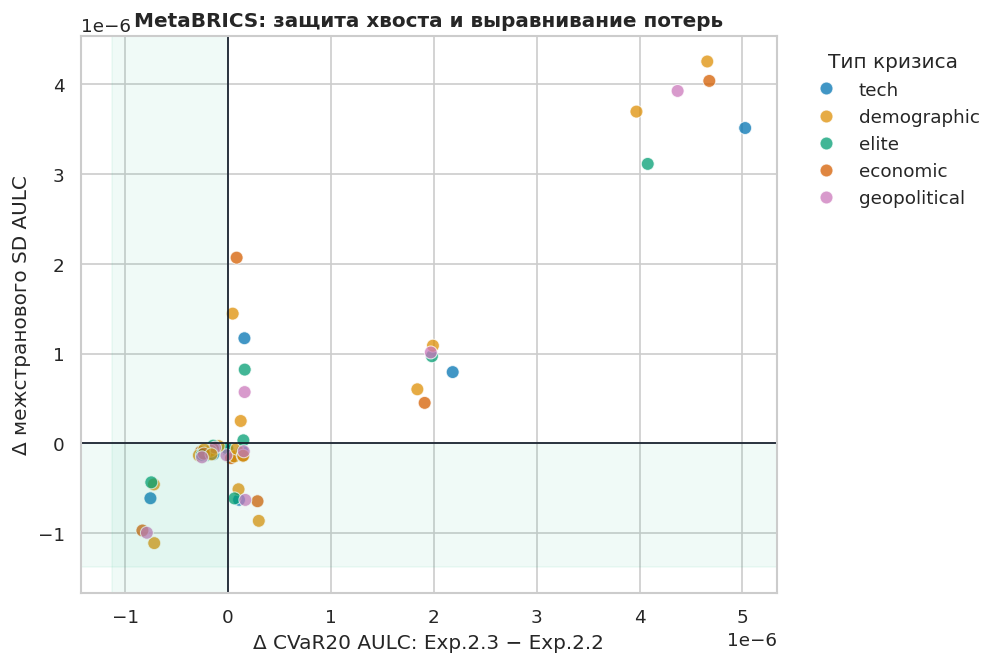

BRICS–PolSys v8.0:  99.9%|█████████▉| 18193/18206 [3:13:43<02:48] , Figures · 4/8

In [35]:
# Фигура 4. MetaBRICS protection frontier: обе отрицательные дельты благоприятны.
ood=LOSS_UNITS[LOSS_UNITS.split=="synthetic_ood"].pivot_table(
    index=["seed","scenario_id","crisis_type"],columns="architecture",values=["cvar20_aulc","aulc_dispersion"]
).dropna()
figure_data=pd.DataFrame({
    "seed":ood.index.get_level_values("seed"),"scenario_id":ood.index.get_level_values("scenario_id"),
    "crisis_type":ood.index.get_level_values("crisis_type"),
    "delta_cvar20":ood[("cvar20_aulc","Exp.2.3")]-ood[("cvar20_aulc","Exp.2.2")],
    "delta_dispersion":ood[("aulc_dispersion","Exp.2.3")]-ood[("aulc_dispersion","Exp.2.2")],
}).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(8.5,5.7))
sns.scatterplot(data=figure_data,x="delta_cvar20",y="delta_dispersion",hue="crisis_type",
                palette="colorblind",s=60,alpha=.75,ax=ax)
ax.axvline(0,color="#111827",lw=1); ax.axhline(0,color="#111827",lw=1)
ax.axvspan(ax.get_xlim()[0],0,color="#10B981",alpha=.06); ax.axhspan(ax.get_ylim()[0],0,color="#10B981",alpha=.06)
ax.set(xlabel="Δ CVaR20 AULC: Exp.2.3 − Exp.2.2",ylabel="Δ межстранового SD AULC",
       title="MetaBRICS: защита хвоста и выравнивание потерь")
ax.legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left",title="Тип кризиса")
save_figure(fig,"04_coalition_protection_frontier",figure_data); FIGURE_STAGE.tick(note="4/8")

In [ ]:
# Фигура 5. Величина адаптации: канон, локальный reference и энтропия весов.
figure_data=EVAL_WEIGHTS.groupby(["architecture","step"],observed=True).agg(
    distance_canonical=("distance_from_canonical","mean"),distance_reference=("distance_from_reference","mean"),
    entropy=("weight_entropy","mean")
).reset_index()
panels=[("distance_canonical","От канона"),("distance_reference","От reference"),("entropy","Энтропия")]
fig,axes=plt.subplots(1,3,figsize=(14,4.2))
for ax,(metric,title) in zip(axes,panels):
    for architecture in ARCHITECTURES:
        block=figure_data[figure_data.architecture==architecture]
        ax.plot(block.step,block[metric],color=ARCH_COLORS[architecture],lw=2,label=architecture)
    ax.set(xlabel="Шаг",ylabel=metric.replace("_"," "),title=title)
axes[-1].legend(frameon=False,bbox_to_anchor=(1.02,1),loc="upper left")
fig.suptitle("Диагностика реальной адаптации канальных весов",y=1.02,fontweight="semibold")
save_figure(fig,"05_weight_adaptation_diagnostics",figure_data); FIGURE_STAGE.tick(note="5/8")

In [ ]:
# Фигура 6. Внутриэпизодная связь proxy drift и валовой награды после удаления средних эпизода.
within=EVAL_TRAJECTORIES.copy(); keys=["seed","architecture","split","scenario_id","country"]
within["drift_within"]=within.proxy_drift-within.groupby(keys,observed=True).proxy_drift.transform("mean")
within["gross_within"]=within.r_gross-within.groupby(keys,observed=True).r_gross.transform("mean")
within["drift_bin"]=pd.qcut(within.drift_within,30,duplicates="drop")
figure_data=within.groupby("drift_bin",observed=True).agg(
    drift_within=("drift_within","mean"),gross_within=("gross_within","mean"),
    gross_se=("gross_within",lambda x:x.std(ddof=1)/math.sqrt(max(len(x),1))),n=("gross_within","size")
).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(8.5,5.4))
ax.errorbar(figure_data.drift_within,figure_data.gross_within,yerr=1.96*figure_data.gross_se,
            fmt="o",color="#4C78A8",ecolor="#94A3B8",capsize=3,alpha=.85)
sns.regplot(data=figure_data,x="drift_within",y="gross_within",scatter=False,color="#111827",
            line_kws={"ls":"--","lw":1.5},ax=ax)
ax.axhline(0,color="#111827",lw=.8); ax.axvline(0,color="#111827",lw=.8)
ax.set(xlabel="Proxy drift: отклонение от среднего эпизода",ylabel="$R_{gross}$: отклонение от среднего эпизода",
       title="Внутриэпизодная цена символико-операционального расхождения")
save_figure(fig,"06_within_episode_proxy_drift",figure_data); FIGURE_STAGE.tick(note="6/8")

In [ ]:
# Фигура 7. PolSys как разложение парных дельт к Exp.1, а не рейтинг государств.
components=["I_stab","I_dev","I_adap","I_leg","I_fb","I_PolSys"]
means=POLSYS_FULL.groupby(["split","architecture"],observed=True)[components].mean().reset_index()
base=means[means.architecture=="Exp.1"].set_index("split")[components]
rows=[]
for row in means.itertuples(index=False):
    for component in components:
        rows.append({"split":row.split,"architecture":row.architecture,"component":component,
                     "delta":getattr(row,component)-base.loc[row.split,component]})
figure_data=pd.DataFrame(rows)
matrix=figure_data.pivot(index=["split","architecture"],columns="component",values="delta").reindex(columns=components)
limit=max(float(np.nanmax(np.abs(matrix.to_numpy()))),1e-5)
fig,ax=plt.subplots(figsize=(10.5,6)); sns.heatmap(
    matrix,annot=True,fmt="+.5f",cmap="vlag",center=0,vmin=-limit,vmax=limit,linewidths=.5,
    cbar_kws={"label":"Δ к Exp.1"},ax=ax)
ax.set(xlabel="Компонент",ylabel="Выборка и архитектура",title="PolSys: функциональное разложение отличий от Exp.1")
save_figure(fig,"07_polsys_components_delta",figure_data); FIGURE_STAGE.tick(note="7/8")

BRICS–PolSys v8.0: 100.0%|█████████▉| 18197/18206 [3:13:47<01:14] , Figures · 8/8

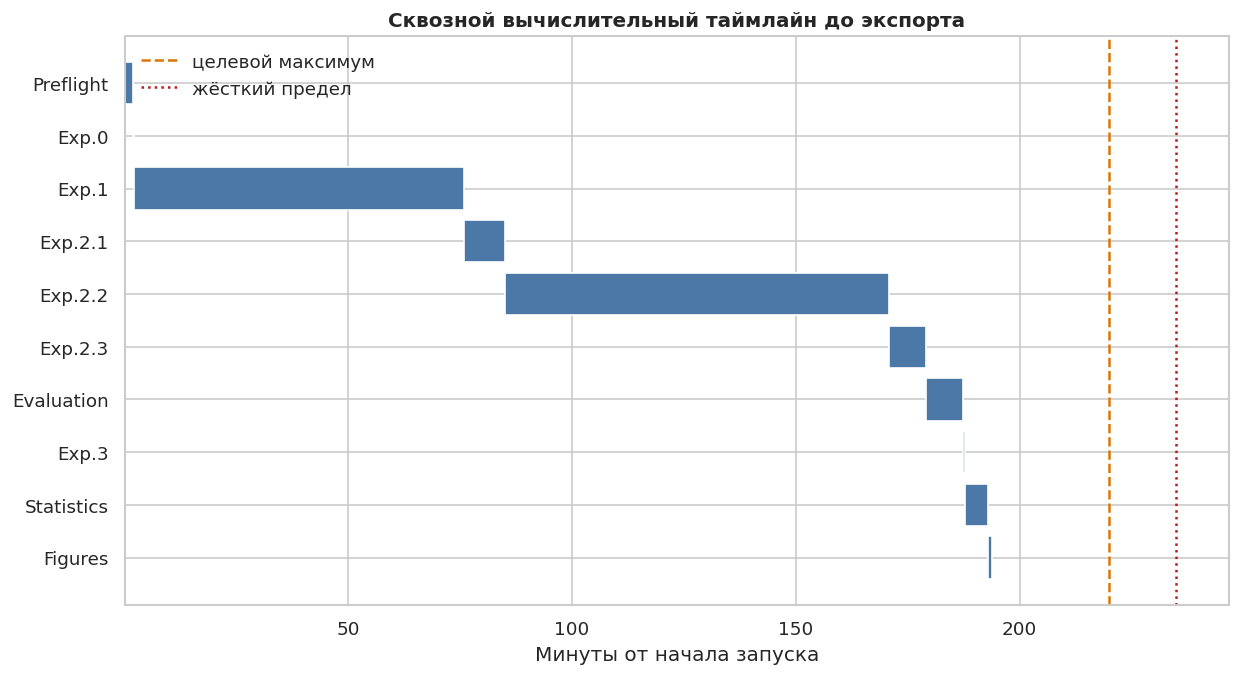

In [39]:
# Фигура 8. Timeline закрывает стадию Figures до чтения журнала, поэтому содержит и визуализацию.
FIGURE_STAGE.tick(note="8/8"); FIGURE_STAGE.__exit__(None,None,None)
figure_data=PROGRESS.frame().copy()
figure_data=figure_data[figure_data.status.isin(["completed","resumed"])].sort_values("started_min")
figure_data=figure_data.drop_duplicates("stage",keep="last")
fig,ax=plt.subplots(figsize=(10.5,5.8)); y=np.arange(len(figure_data))
ax.barh(y,figure_data.duration_min,left=figure_data.started_min,color="#4C78A8")
ax.set_yticks(y,figure_data.stage); ax.invert_yaxis()
ax.set(xlabel="Минуты от начала запуска",ylabel="",title="Сквозной вычислительный таймлайн до экспорта")
ax.axvline(CFG.target_runtime_max,color="#D97706",ls="--",label="целевой максимум")
ax.axvline(CFG.hard_runtime_min,color="#B91C1C",ls=":",label="жёсткий предел")
ax.legend(frameon=False)
save_figure(fig,"08_runtime_timeline",figure_data)

## 18. Компактный Excel-экспорт и исследовательский архив

V8 не создаёт обязательную книгу на 50–70 МБ. Вместо сырых временных строк механизмов по умолчанию
экспортируются страновые эпизоды, коалиционные потери, агрегаты весов и точные данные фигур.
Этого достаточно для проверки всех 17 гипотез и содержательной интерпретации.

1. `01_Overview.xlsx` — дизайн, онтология, world-model gate, endpoint, потери и гипотезы.
2. `02_Inference_Units.xlsx` — seed×scenario, страновые исходы и функциональные потери.
3. `03_Mechanisms_Compact.xlsx` — аналитические механизм-единицы и динамика весов в сжатом виде.
4. `04_PolSys.xlsx` — компоненты и парные дельты к Exp.1.
5. `05_Figure_Data.xlsx` — точные источники восьми фигур.

Сырые механизм-шаги добавляются только при ручном `CFG.export_full_mechanism_steps=True`.
Checkpoint, cache, оптимизаторы и служебные логи в ZIP не включаются.

In [40]:
EXCEL_MAX_DATA_ROWS=1_048_000


def excel_safe(frame:pd.DataFrame)->pd.DataFrame:
    out=frame.copy()
    for column in out.select_dtypes(include=["object"]).columns:
        out[column]=out[column].map(
            lambda x:json.dumps(x,ensure_ascii=False) if isinstance(x,(dict,list,tuple,set)) else x)
    return out.replace([np.inf,-np.inf],np.nan)


def write_styled_sheet(writer:pd.ExcelWriter,name:str,frame:pd.DataFrame,startrow:int=0)->None:
    safe=excel_safe(frame); safe.to_excel(writer,sheet_name=name[:31],index=False,startrow=startrow)
    worksheet,workbook=writer.sheets[name[:31]],writer.book
    header=workbook.add_format({"bold":True,"font_color":"white","bg_color":"#1F4E78",
                                "text_wrap":True,"valign":"top"})
    for col,value in enumerate(safe.columns):
        worksheet.write(startrow,col,value,header)
        sample=safe[value].astype(str).head(200) if len(safe) else pd.Series(dtype=str)
        width=min(42,max(11,len(str(value))+2,
                         int(sample.str.len().quantile(.90))+2 if len(sample) else 11))
        worksheet.set_column(col,col,width)
    worksheet.freeze_panes(startrow+1,0)
    if len(safe):
        worksheet.autofilter(startrow,0,startrow+len(safe),len(safe.columns)-1)


def write_chunked_sheet(writer:pd.ExcelWriter,base_name:str,frame:pd.DataFrame)->list[str]:
    names=[]
    for part,start in enumerate(range(0,max(1,len(frame)),EXCEL_MAX_DATA_ROWS),start=1):
        name=base_name if len(frame)<=EXCEL_MAX_DATA_ROWS else f"{base_name}_{part:02d}"
        write_styled_sheet(writer,name,frame.iloc[start:start+EXCEL_MAX_DATA_ROWS]); names.append(name[:31])
    return names


def write_workbook(path:Path,sheets:Mapping[str,pd.DataFrame])->Path:
    with pd.ExcelWriter(path,engine="xlsxwriter",
                        engine_kwargs={"options":{"nan_inf_to_errors":True,"strings_to_urls":False}}) as writer:
        for name,frame in sheets.items():
            write_chunked_sheet(writer,name,frame)
        writer.book.set_properties({
            "title":f"{CFG.project} {CFG.version}","subject":"Research outputs",
            "author":"BRICS–PolSys MARL research pipeline",
            "comments":"Model-internal counterfactual experiment; not a country ranking.",
        })
    return path


def readme_frame(rows:Sequence[tuple[str,str]])->pd.DataFrame:
    return pd.DataFrame(rows,columns=["Раздел","Описание"])


def penalty_ablation_table(trajectories:pd.DataFrame)->pd.DataFrame:
    variants={
        "baseline":(CFG.coord_penalty,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),
        "coord_0x":(0.0,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),
        "coord_2x":(2*CFG.coord_penalty,CFG.uncertainty_penalty,CFG.proxy_drift_penalty),
        "uncertainty_0x":(CFG.coord_penalty,0.0,CFG.proxy_drift_penalty),
        "uncertainty_2x":(CFG.coord_penalty,2*CFG.uncertainty_penalty,CFG.proxy_drift_penalty),
        "proxy_drift_0x":(CFG.coord_penalty,CFG.uncertainty_penalty,0.0),
        "proxy_drift_2x":(CFG.coord_penalty,CFG.uncertainty_penalty,2*CFG.proxy_drift_penalty),
    }
    rows=[]
    for name,(coord,uncertainty,drift) in variants.items():
        values=(trajectories.r_gross-coord*trajectories.coordination_cost
                -uncertainty*trajectories.uncertainty-drift*trajectories.proxy_drift)
        temp=trajectories[["seed","architecture","split","scenario_id"]].copy()
        temp["r_net_ablation"]=values
        agg=temp.groupby(["seed","architecture","split","scenario_id"],observed=True).r_net_ablation.mean().reset_index()
        agg["variant"],agg["coord_coef"],agg["uncertainty_coef"],agg["proxy_drift_coef"]=name,coord,uncertainty,drift
        rows.append(agg)
    return pd.concat(rows,ignore_index=True)


def seed_point_table(frame:pd.DataFrame)->pd.DataFrame:
    return frame.groupby(["seed","architecture","split"],observed=True).agg(
        mean_r_net=("mean_r_net","mean"),mean_r_gross=("mean_r_gross","mean"),
        median_r_net=("mean_r_net","median"),bottom20_r_net=("bottom20_r_net","mean"),
        country_r_net_sd=("country_r_net_sd","mean"),mean_proxy_drift=("mean_proxy_drift","mean"),
        mean_coordination_cost=("mean_coordination_cost","mean"),
    ).reset_index()


def scenario_registry_table()->pd.DataFrame:
    rows=[]
    for split in ("observed_holdout","synthetic_ood"):
        for scenario in EVAL_SCENARIOS[split]:
            rows.append({
                "split":split,"scenario_id":scenario.scenario_id,"scenario_name":scenario.name,
                "start_year":scenario.start_year,"end_year":scenario.end_year,
                "crisis_type":scenario.crisis_type,"crisis_ids":";".join(str(c.id) for c in scenario.crises),
                "n_crises":len(scenario.crises),"compound":scenario.compound,
                "stress_multiplier":scenario.stress_multiplier,"aftershock_ratio":scenario.aftershock_ratio,
                "tail_decay":scenario.tail_decay,
            })
    return pd.DataFrame(rows)


def mechanism_unit_table()->pd.DataFrame:
    keys=["seed","architecture","split","scenario_id","country"]
    recovery_columns=keys+["aulc","peak_loss","persistent_loss_share","late_loss","recovery_time",
                           "event_observed","baseline_functional","recovery_tolerance"]
    return EVAL_COUNTRY.merge(RECOVERY[recovery_columns],on=keys,how="left",validate="one_to_one")


def weight_summaries(weights:pd.DataFrame)->tuple[pd.DataFrame,pd.DataFrame]:
    keys=["seed","architecture","split","scenario_id","scenario_name","crisis_type","country"]
    unit=weights.groupby(keys,observed=True).agg(
        deeds_mean=("weight_deeds","mean"),words_mean=("weight_words","mean"),images_mean=("weight_images","mean"),
        deeds_sd=("weight_deeds","std"),words_sd=("weight_words","std"),images_sd=("weight_images","std"),
        canonical_distance=("distance_from_canonical","mean"),reference_distance=("distance_from_reference","mean"),
        entropy_mean=("weight_entropy","mean"),
    ).reset_index()
    ordered=weights.sort_values(keys+["step"]).copy()
    ordered["path_increment"]=(ordered.groupby(keys,observed=True)[["weight_deeds","weight_words","weight_images"]]
                                .diff().abs().mean(axis=1).fillna(0))
    path=ordered.groupby(keys,observed=True).path_increment.sum().rename("weight_path_length").reset_index()
    unit=unit.merge(path,on=keys,validate="one_to_one")
    step=weights.groupby(["architecture","split","step"],observed=True).agg(
        deeds_mean=("weight_deeds","mean"),words_mean=("weight_words","mean"),images_mean=("weight_images","mean"),
        canonical_distance=("distance_from_canonical","mean"),reference_distance=("distance_from_reference","mean"),
        entropy_mean=("weight_entropy","mean"),
    ).reset_index()
    return unit,step


PENALTY_ABLATIONS=penalty_ablation_table(EVAL_TRAJECTORIES)
ENDPOINT_SUMMARY=bootstrap_endpoint_table(EVAL_COALITION)
LOSS_ENDPOINT_SUMMARY=bootstrap_loss_table(LOSS_UNITS)
SEED_POINTS=seed_point_table(EVAL_COALITION)
SCENARIO_REGISTRY=scenario_registry_table()
MECHANISM_UNITS=mechanism_unit_table()
WEIGHT_UNITS,WEIGHT_STEPS=weight_summaries(EVAL_WEIGHTS)
training_summary=pd.concat([
    EXP1_TRAINING.groupby("seed").agg(iterations=("episode","max"),best_validation=("validation_reward","max")).assign(stage="Exp.1").reset_index(),
    EXP21_TRAINING.groupby("seed").agg(iterations=("round","max"),best_validation=("best_fitness","max")).assign(stage="Exp.2.1").reset_index(),
    EXP22_TRAINING.groupby("seed").agg(iterations=("round","sum"),best_validation=("best_fitness","max")).assign(stage="Exp.2.2").reset_index(),
    EXP23_TRAINING.groupby("seed").agg(iterations=("round","max"),best_validation=("best_objective","max")).assign(stage="Exp.2.3").reset_index(),
],ignore_index=True)
EXPORT_STAGE=PROGRESS.stage("Export"); EXPORT_STAGE.__enter__(); EXPORT_STAGE.tick(note="аналитические сводки")

BRICS–PolSys v8.0: 100.0%|█████████▉| 18199/18206 [3:18:32<04:51] , Export · аналитические сводки

In [ ]:
state_dictionary=pd.DataFrame([{
    "position":i,"name":name,"block":next(block for block,names in STATE_BLOCKS.items() if name in names),
    "definition":STATE_DEFINITIONS[name],
    "orientation":"negative" if name in NEGATIVE_STATE_FEATURES else "neutral" if name in NEUTRAL_STATE_FEATURES else "positive",
} for i,name in enumerate(STATE_NAMES)])
action_dictionary=pd.DataFrame([{
    "position":i,"name":name,"group":next(group for group,idx in ACTION_GROUPS.items() if i in idx),
    "definition":ACTION_DEFINITIONS[name],
} for i,name in enumerate(ACTION_NAMES)])
design=pd.DataFrame([{"parameter":key,"value":json.dumps(value,ensure_ascii=False) if isinstance(value,(dict,list,tuple)) else value}
                     for key,value in {**asdict(CFG),"selected_profile":asdict(PROFILE),
                                       "world_dynamics_mode":WORLD_DYNAMICS_MODE}.items()])
overview_readme=readme_frame([
    ("Назначение","Главная книга для интерпретации дизайна, эффектов, потерь и 17 гипотез."),
    ("Architecture_Summary","Валовой и чистый endpoint с иерархическими интервалами."),
    ("Loss_Summary","AULC, CVaR20, worst-country и dispersion с иерархическими интервалами."),
    ("Hypotheses","Primary: Holm и seed-cluster exact sign-flip; exploratory: FDR-BH."),
    ("Ограничение","Модельный контрфактический эксперимент; не прогноз и не рейтинг стран."),
])
OVERVIEW_PATH=write_workbook(XLSX_DIR/"01_Overview.xlsx",{
    "README":overview_readme,"Run_Metadata":pd.DataFrame([{"key":k,"value":v} for k,v in RUN_METADATA.items()]),
    "Design":design,"Scenario_Registry":SCENARIO_REGISTRY,"State_Ontology":state_dictionary,
    "Action_Ontology":action_dictionary,"World_Model_Validation":WM_METRICS,
    "Architecture_Summary":ENDPOINT_SUMMARY,"Loss_Summary":LOSS_ENDPOINT_SUMMARY,
    "Seed_Points":SEED_POINTS,"Training_Summary":training_summary,
    "Penalty_Ablations":PENALTY_ABLATIONS,"Hypotheses":HYPOTHESIS_RESULTS,
}); EXPORT_STAGE.tick(note="01_Overview.xlsx")

In [ ]:
inference_readme=readme_frame([
    ("Coalition_Episodes","Primary-уровень seed × scenario × architecture."),
    ("Country_Episodes","Страны вложены в seed × scenario; таблица не является рейтингом."),
    ("Recovery_Country","AULC от onset, peak, persistent/late loss и диагностическое recovery-time."),
    ("Coalition_Loss","Mean, worst-country, CVaR20, dispersion и Gini функциональных потерь."),
])
INFERENCE_PATH=write_workbook(XLSX_DIR/"02_Inference_Units.xlsx",{
    "README":inference_readme,"Coalition_Episodes":EVAL_COALITION,"Country_Episodes":EVAL_COUNTRY,
    "Recovery_Country":RECOVERY,"Coalition_Loss":LOSS_UNITS,
}); EXPORT_STAGE.tick(note="02_Inference_Units.xlsx")

mechanism_readme=readme_frame([
    ("Mechanism_Units","Страновой эпизод: rewards, channels, shocks, исходные модераторы и потери."),
    ("Weight_Units","Средние/SD весов, расстояния от канона/reference, энтропия и path length."),
    ("Weight_Steps","Компактная средняя динамика весов по architecture × split × step."),
    ("Mechanism_Evidence","Exploratory E1–E12 с эффектами, CI и FDR."),
    ("Raw steps","По умолчанию исключены; включаются флагом export_full_mechanism_steps."),
])
mechanism_sheets={
    "README":mechanism_readme,"Mechanism_Units":MECHANISM_UNITS,"Weight_Units":WEIGHT_UNITS,
    "Weight_Steps":WEIGHT_STEPS,
    "Mechanism_Evidence":HYPOTHESIS_RESULTS[HYPOTHESIS_RESULTS.family=="exploratory"],
}
if CFG.export_full_mechanism_steps:
    state_needed=["SDI","ECI","MPI","DPI",*STATE_BLOCKS["strategic"]]
    columns=["seed","architecture","split","scenario_id","scenario_name","crisis_type","country","step",
             "r_gross","r_net","y_deeds","y_words","y_images","cohesion","risk","coordination_cost",
             "coord_adjustment","coord_dispersion","coord_churn","uncertainty","proxy_drift","shock_intensity",
             *[f"state__{x}" for x in state_needed],*[f"action__{x}" for x in ACTION_NAMES]]
    mechanism_sheets["Optional_Raw_Steps"]=EVAL_TRAJECTORIES.loc[:,columns]
    mechanism_sheets["Optional_Raw_Weights"]=EVAL_WEIGHTS
MECHANISM_PATH=write_workbook(XLSX_DIR/"03_Mechanisms_Compact.xlsx",mechanism_sheets)
EXPORT_STAGE.tick(note="03_Mechanisms_Compact.xlsx")

In [ ]:
component_definitions=pd.DataFrame([
    ("I_stab","функциональная стабильность и ограничение риска",.25),
    ("I_dev","социальное развитие и операциональный канал дел",.20),
    ("I_adap","AULC, peak loss и доля устойчивой потери",.20),
    ("I_leg","легитимность, доверие и канал слов",.20),
    ("I_fb","обратная связь без proxy drift и word–deed gap",.15),
    ("I_PolSys","взвешенная эндогенная постоценка пяти компонентов",1.00),
    ("delta_I_PolSys_vs_Exp1","парная дельта относительно Exp.1; не рейтинг",np.nan),
],columns=["component","definition","weight"])
polsys_readme=readme_frame([
    ("PolSys_Full","Одна строка = seed × architecture × split × scenario × country."),
    ("PolSys_Summary","Среднее, медиана и SD; страны расположены алфавитно."),
    ("Интерпретация","Эндогенная модельная постоценка, не универсальная шкала режимов."),
])
POLSYS_PATH=write_workbook(XLSX_DIR/"04_PolSys.xlsx",{
    "README":polsys_readme,"Component_Definitions":component_definitions,
    "PolSys_Full":POLSYS_FULL,"PolSys_Summary":POLSYS_SUMMARY,
}); EXPORT_STAGE.tick(note="04_PolSys.xlsx")

In [ ]:
figure_readme=readme_frame([(slug,f"Точный источник фигуры {slug}; PNG/SVG находятся в figures.")
                            for slug in FIGURE_DATA])
figure_sheets={"README":figure_readme}
for index,(slug,frame) in enumerate(FIGURE_DATA.items(),start=1):
    figure_sheets[f"F{index:02d}_{slug[3:25]}"]=frame
FIGURE_DATA_PATH=write_workbook(XLSX_DIR/"05_Figure_Data.xlsx",figure_sheets)
EXPORT_STAGE.tick(note="05_Figure_Data.xlsx")

In [ ]:
RUN_METADATA["finished_utc"]=pd.Timestamp.utcnow().isoformat()
RUN_METADATA["elapsed_minutes_before_zip"]=round(PROGRESS.elapsed_min(),2)
readme_text=f"""# BRICS–PolSys MARL v{CFG.version}: результаты

Контрфактический многоагентный эксперимент; не прогноз и не рейтинг государств.

## Порядок чтения
1. `excel/01_Overview.xlsx`: дизайн, сценарии, gate, endpoint, потери и 17 гипотез.
2. `excel/02_Inference_Units.xlsx`: независимые единицы и страновые/коалиционные потери.
3. `excel/03_Mechanisms_Compact.xlsx`: компактные механизм-единицы и диагностика весов.
4. `excel/04_PolSys.xlsx`: компоненты и парные дельты к Exp.1.
5. `excel/05_Figure_Data.xlsx`: точные источники восьми графиков.

Primary: Holm; exploratory: FDR-BH. Независимая единица — seed; сценарии вложены в seed.
Exact sign-flip назначает один знак всем сценариям seed. World dynamics: {WORLD_DYNAMICS_MODE}.
Профиль: {PROFILE.name}. Сиды: {', '.join(map(str,CFG.seeds))}. Горизонт: {CFG.horizon}.
"""
(GUIDE_DIR/"README_RESULTS.md").write_text(textwrap.dedent(readme_text),encoding="utf-8")
contents="""# Содержание архива

| Путь | Назначение |
|---|---|
| `excel/01_Overview.xlsx` | дизайн, онтология, сценарии, gate, endpoint, 17 гипотез |
| `excel/02_Inference_Units.xlsx` | seed×scenario, recovery и распределительные потери |
| `excel/03_Mechanisms_Compact.xlsx` | компактные механизмы и веса |
| `excel/04_PolSys.xlsx` | компоненты и парные дельты |
| `excel/05_Figure_Data.xlsx` | данные восьми фигур |
| `figures/*.png`, `figures/*.svg` | публикационные изображения |
| `guides/*.md` | инструкция по интерпретации |

Сырые временные шаги по умолчанию не экспортируются. Checkpoint, cache, оптимизаторы и служебные
логи исключены.
"""
(GUIDE_DIR/"ARCHIVE_CONTENTS.md").write_text(textwrap.dedent(contents),encoding="utf-8")
EXPORT_STAGE.tick(note="гиды")

ARCHIVE_PATH=Path("/content")/"BRICS_PolSys_MARL_v8_0_results.zip"
if ARCHIVE_PATH.exists():
    ARCHIVE_PATH.unlink()
with zipfile.ZipFile(ARCHIVE_PATH,"w",compression=zipfile.ZIP_DEFLATED,compresslevel=7) as archive:
    for path in sorted(ROOT.rglob("*")):
        if path.is_file():
            archive.write(path,path.relative_to(ROOT.parent))
EXPORT_STAGE.tick(note="ZIP"); EXPORT_STAGE.__exit__(None,None,None); PROGRESS.close()
if not CFG.keep_checkpoints and CHECKPOINT_DIR.exists():
    shutil.rmtree(CHECKPOINT_DIR)
print(f"Архив: {ARCHIVE_PATH} · {ARCHIVE_PATH.stat().st_size/1024**2:.1f} MB")
print(pd.DataFrame(PROGRESS.timeline)[["stage","duration_min","completed_units","unused_units","status"]].to_string(index=False))

In [46]:
# Финальная загрузка архива в браузер Colab.
try:
    from google.colab import files
    files.download(str(ARCHIVE_PATH))
except ImportError:
    print(f"Загрузка доступна в Colab; локальный путь: {ARCHIVE_PATH}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Сохранение исполненного ноутбука на GitHub

После загрузки ZIP выберите в Colab **File → Save a copy in GitHub**. Ноутбук использует только
статические таблицы, изображения и один текстовый progress-bar; `ipywidgets` не требуются.
Сохраните научные выводы и восемь фигур, но удалите случайно выведенные персональные пути, если они есть.